In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [3]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- PaperlessBilling ---
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- Churn ---
Churn
No     5174
Yes    1869
Name: count

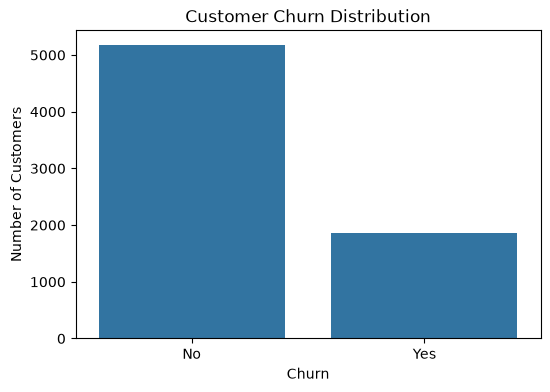

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


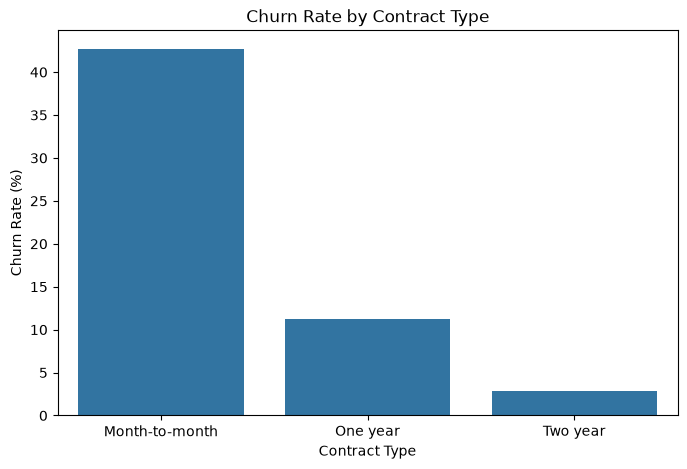

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn.reset_index(),
    x="Contract",
    y="Yes"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [11]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49+ months"],
    include_lowest=True
)

print(df["tenure_group"].value_counts().sort_index())

tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49+ months      2239
Name: count, dtype: int64


In [12]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                No        Yes
tenure_group                      
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49+ months    90.486824   9.513176


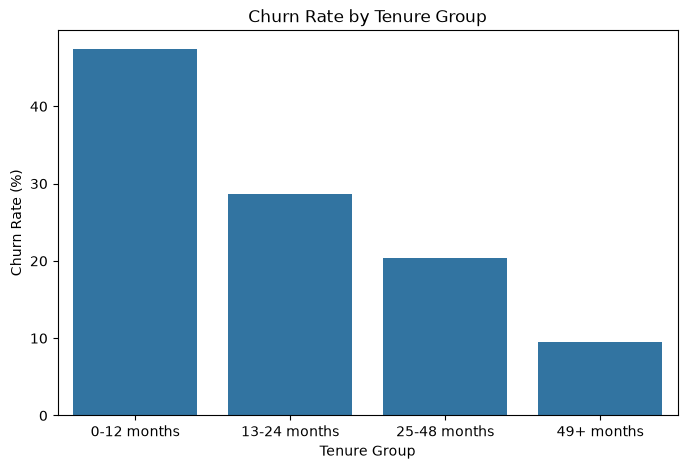

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tenure_churn.reset_index(),
    x="tenure_group",
    y="Yes"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [14]:
df["monthly_charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 70, 100, float("inf")],
    labels=["Below $35", "$35-$70", "$70-$100", "$100+"]
)

monthly_churn = pd.crosstab(
    df["monthly_charge_group"],
    df["Churn"],
    normalize="index"
) * 100

print(monthly_churn)

Churn                        No        Yes
monthly_charge_group                      
Below $35             89.106628  10.893372
$35-$70               76.057971  23.942029
$70-$100              62.178292  37.821708
$100+                 71.951220  28.048780


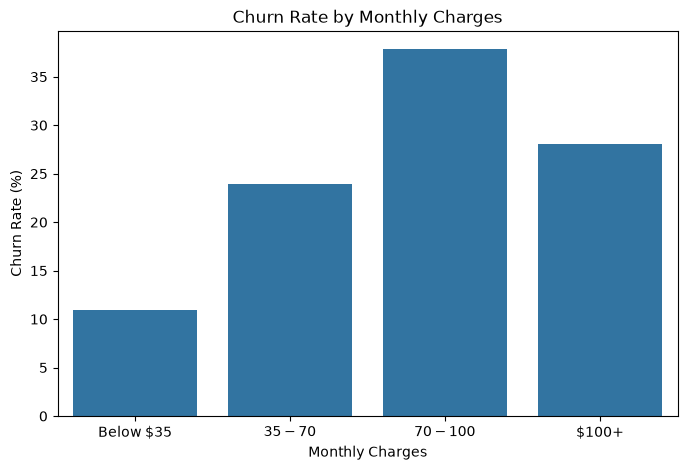

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=monthly_churn.reset_index(),
    x="monthly_charge_group",
    y="Yes"
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")

plt.show()

In [16]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


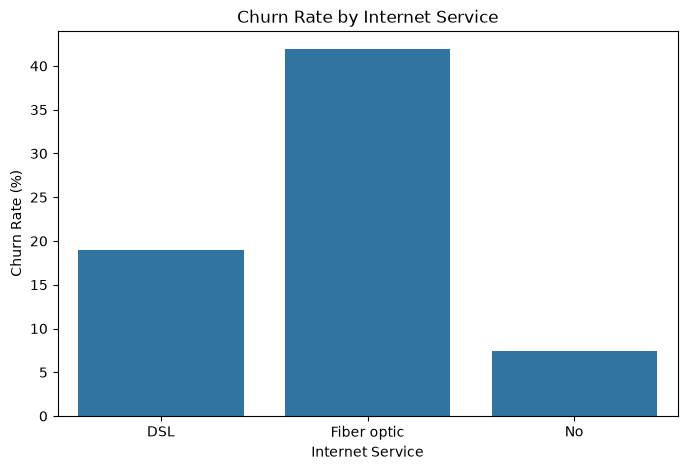

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn.reset_index(),
    x="InternetService",
    y="Yes"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [18]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


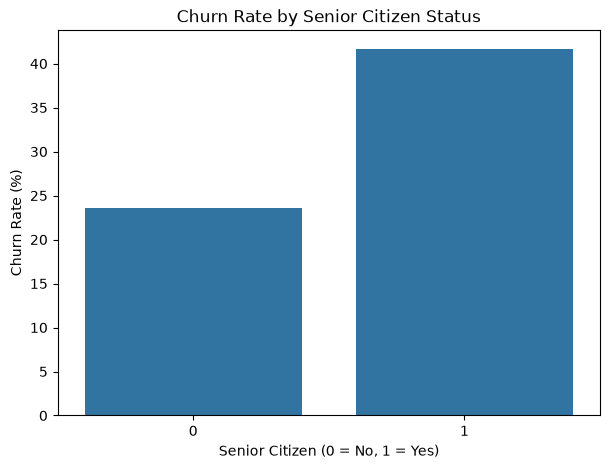

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=senior_churn.reset_index(),
    x="SeniorCitizen",
    y="Yes"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.show()

In [20]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


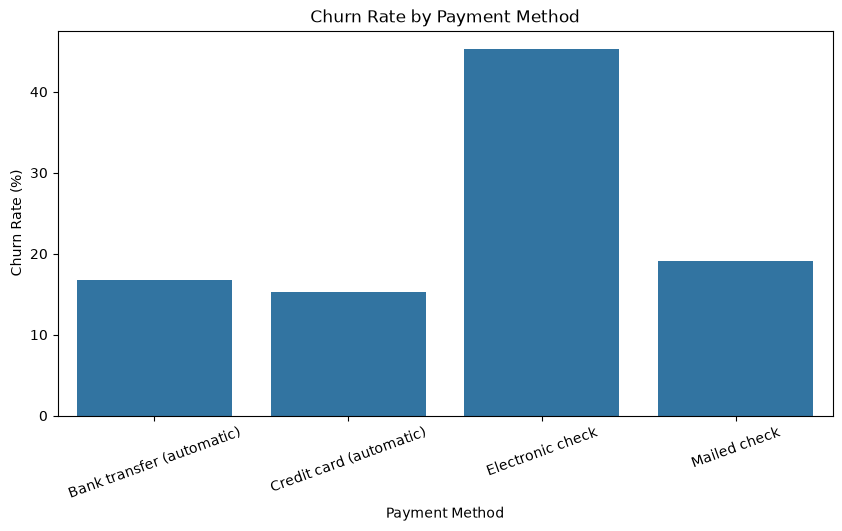

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn.reset_index(),
    x="PaymentMethod",
    y="Yes"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [22]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print(paperless_churn)

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


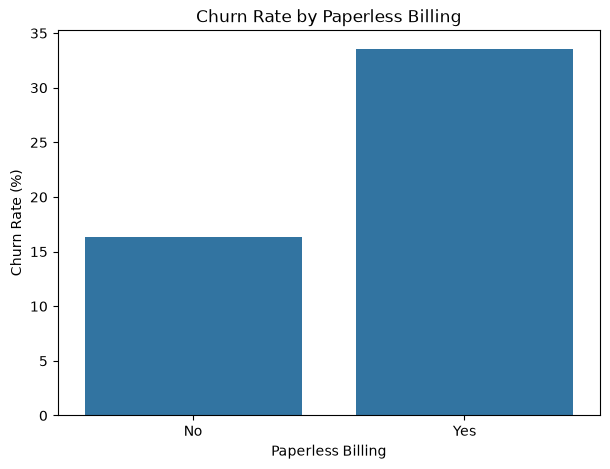

In [23]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=paperless_churn.reset_index(),
    x="PaperlessBilling",
    y="Yes"
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.show()

In [24]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn)

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


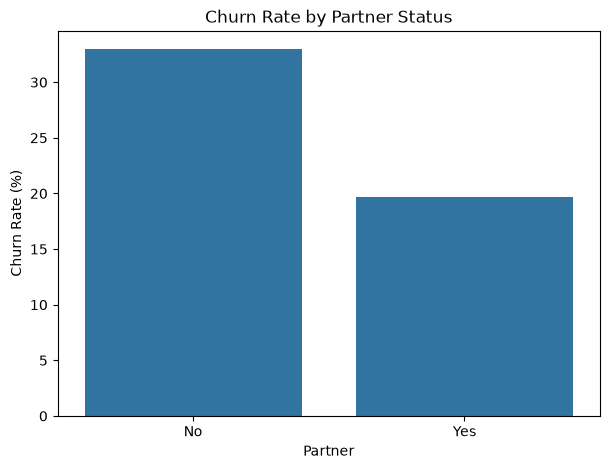

In [25]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=partner_churn.reset_index(),
    x="Partner",
    y="Yes"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.show()

In [26]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print(dependents_churn)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


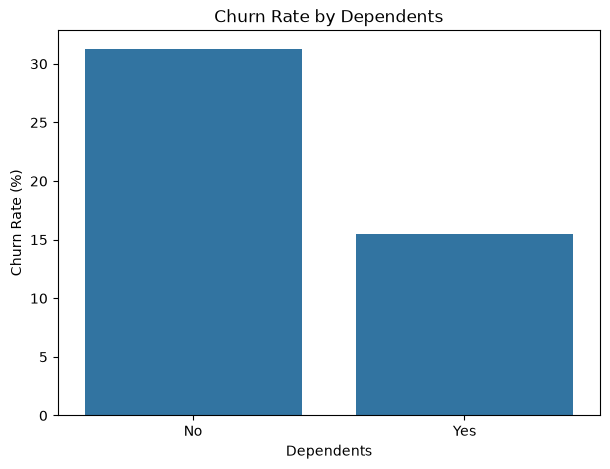

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=dependents_churn.reset_index(),
    x="Dependents",
    y="Yes"
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.show()

In [28]:
phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

print(phone_churn)

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


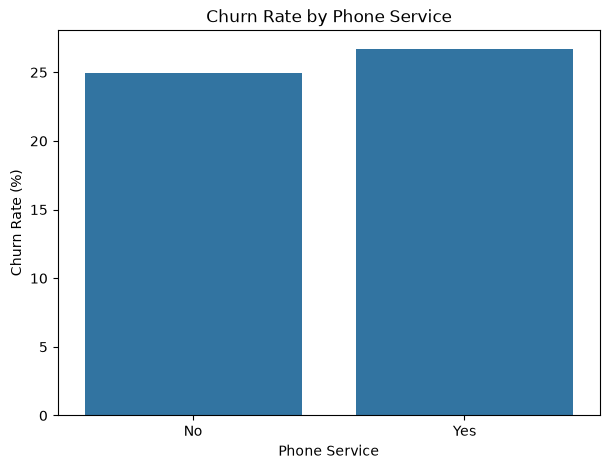

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=phone_churn.reset_index(),
    x="PhoneService",
    y="Yes"
)

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [30]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(security_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


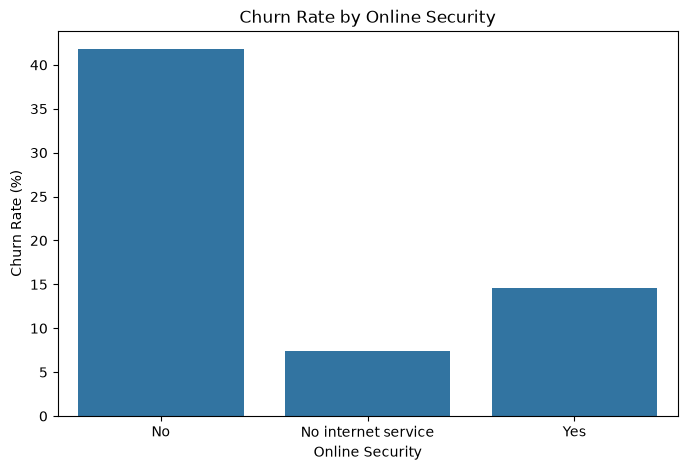

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=security_churn.reset_index(),
    x="OnlineSecurity",
    y="Yes"
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.show()

In [32]:
backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

print(backup_churn)

Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


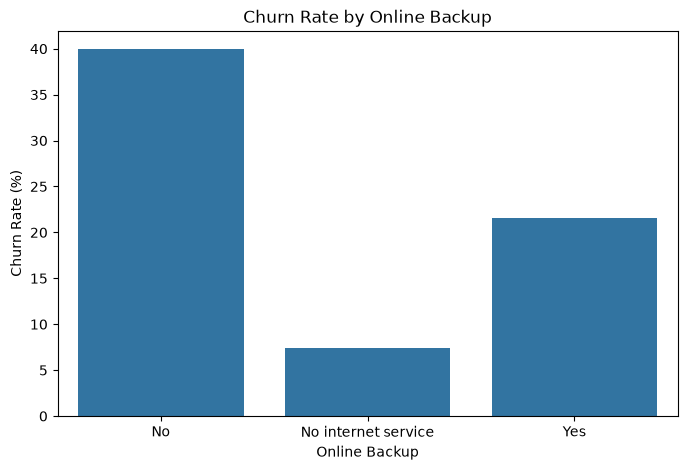

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=backup_churn.reset_index(),
    x="OnlineBackup",
    y="Yes"
)

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.show()

In [34]:
device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

print(device_churn)

Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


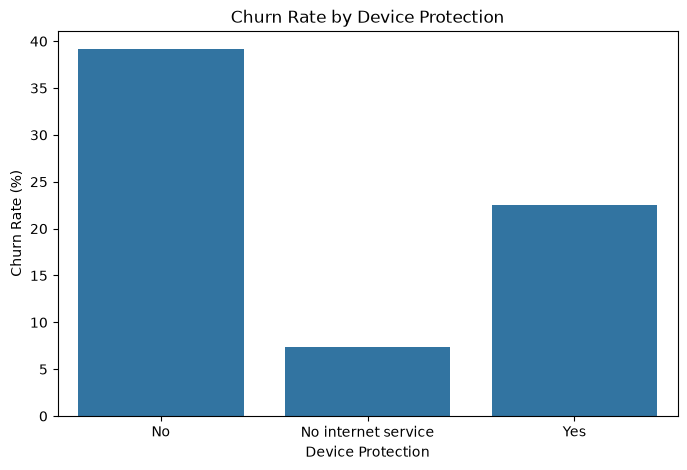

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_churn.reset_index(),
    x="DeviceProtection",
    y="Yes"
)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.show()

In [36]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(techsupport_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


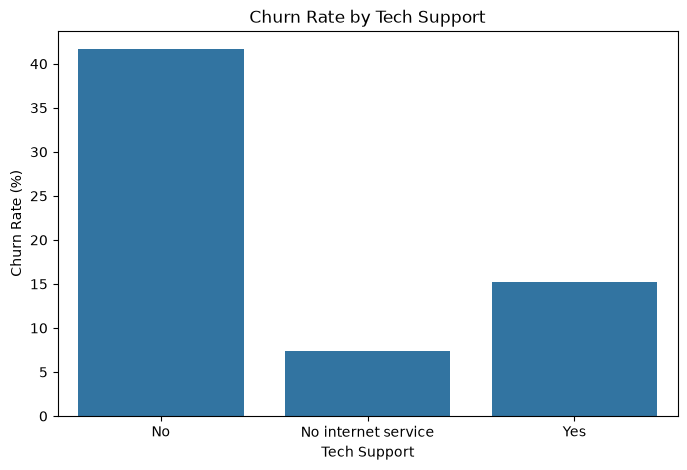

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=techsupport_churn.reset_index(),
    x="TechSupport",
    y="Yes"
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

In [38]:
streamingtv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

print(streamingtv_churn)

Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188


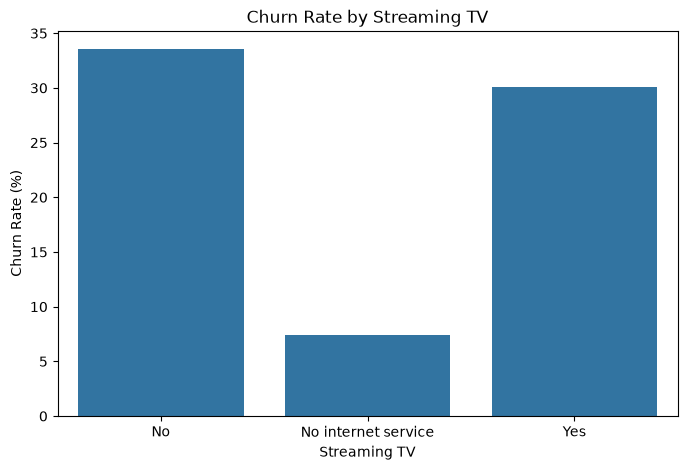

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=streamingtv_churn.reset_index(),
    x="StreamingTV",
    y="Yes"
)

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.show()

In [40]:
streamingmovies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

print(streamingmovies_churn)

Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435


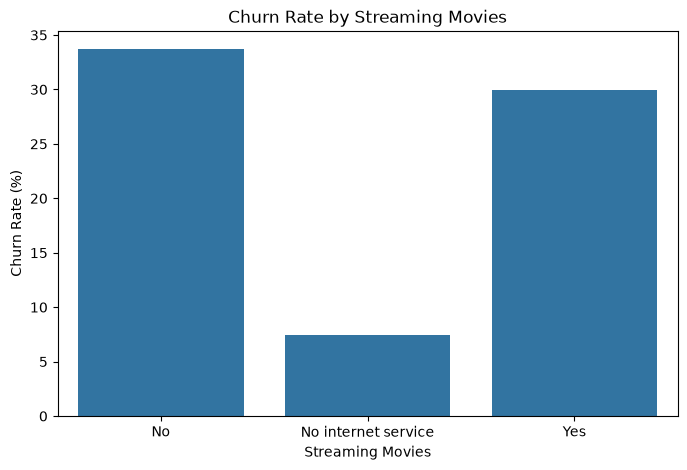

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=streamingmovies_churn.reset_index(),
    x="StreamingMovies",
    y="Yes"
)

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.show()

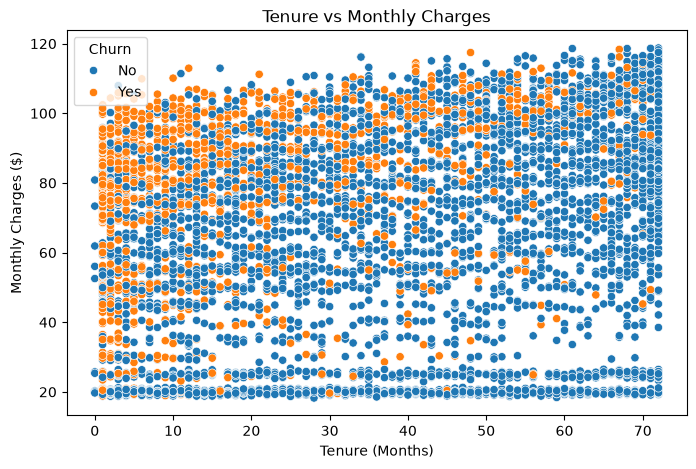

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.show()

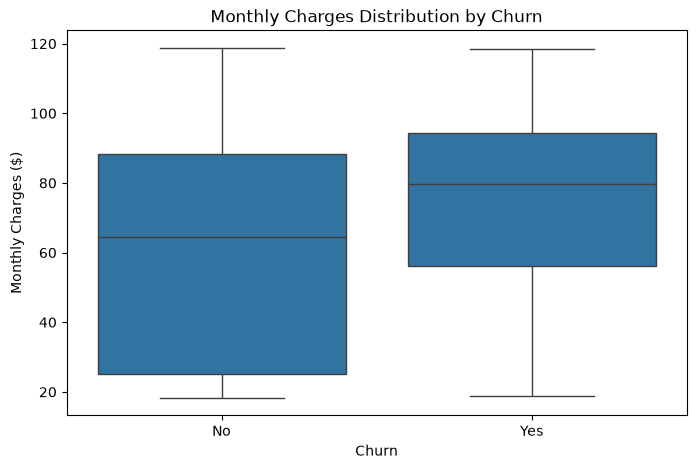

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()

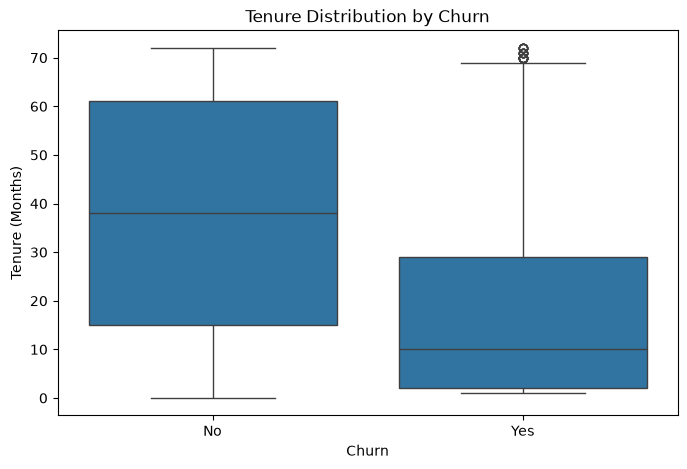

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [45]:
correlation = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges"]
].corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


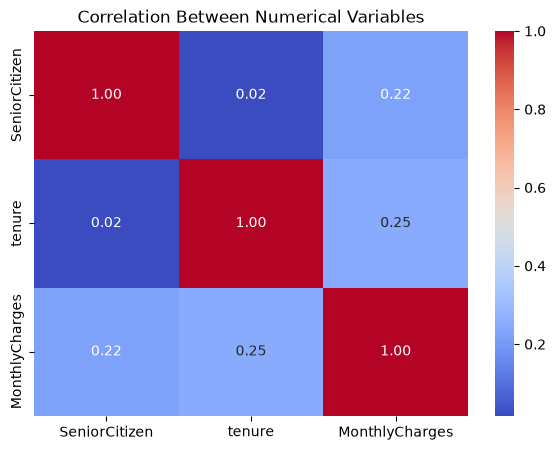

In [46]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

In [47]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


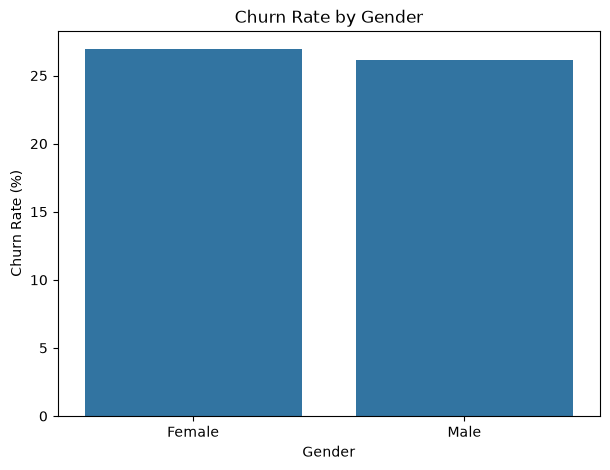

In [48]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn.reset_index(),
    x="gender",
    y="Yes"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

In [49]:
df["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

churn_correlation = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "Churn_numeric"]
].corr()

print(churn_correlation)

                SeniorCitizen    tenure  MonthlyCharges  Churn_numeric
SeniorCitizen        1.000000  0.016567        0.220173       0.150889
tenure               0.016567  1.000000        0.247900      -0.352229
MonthlyCharges       0.220173  0.247900        1.000000       0.193356
Churn_numeric        0.150889 -0.352229        0.193356       1.000000


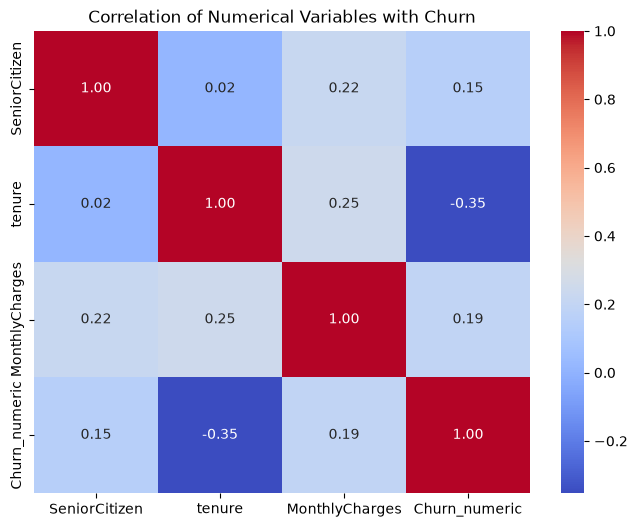

In [50]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    churn_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Numerical Variables with Churn")
plt.show()

In [51]:
contract_internet_churn = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

print(contract_internet_churn)

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699


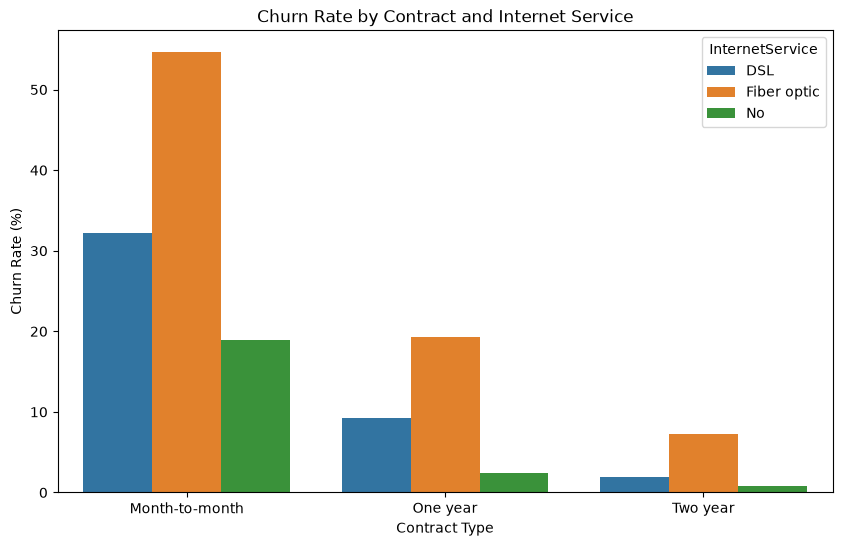

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=contract_internet_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="InternetService"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [53]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["service_count"] = 0

for column in service_columns:
    df["service_count"] += (
        df[column] == "Yes"
    ).astype(int)

print(df["service_count"].value_counts().sort_index())

service_count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


In [54]:
service_churn = pd.crosstab(
    df["service_count"],
    df["Churn"],
    normalize="index"
) * 100

print(service_churn)

Churn                 No        Yes
service_count                      
0              78.593961  21.406039
1              54.244306  45.755694
2              64.181994  35.818006
3              72.629696  27.370304
4              77.699531  22.300469
5              87.565674  12.434326
6              94.718310   5.281690


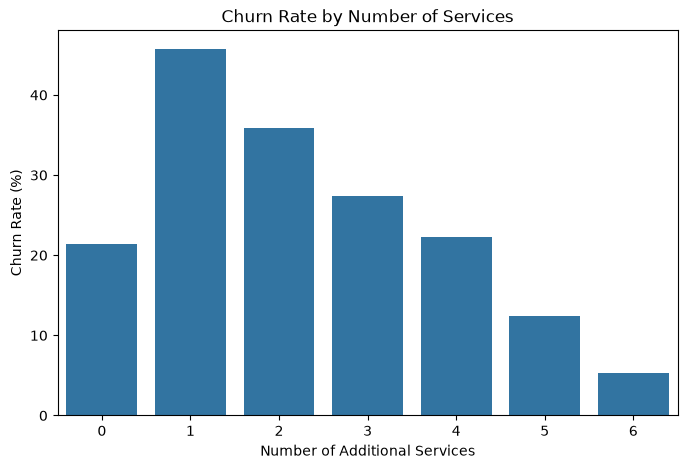

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=service_churn.reset_index(),
    x="service_count",
    y="Yes"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Additional Services")
plt.ylabel("Churn Rate (%)")
plt.show()

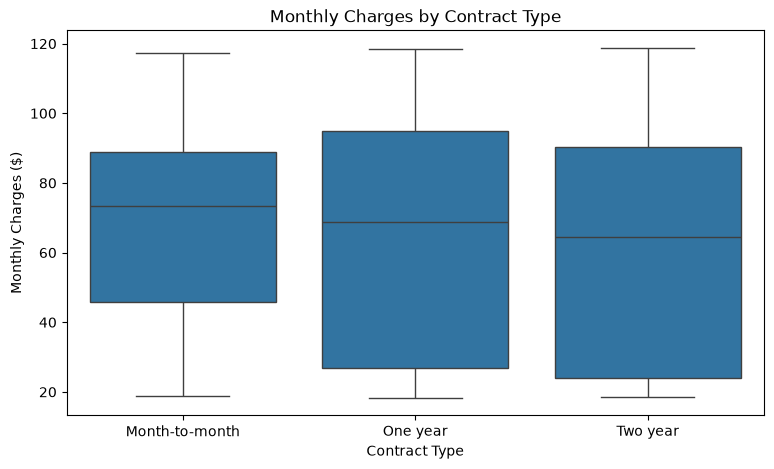

In [56]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges ($)")
plt.show()

In [57]:
phone_internet_churn = pd.crosstab(
    [df["PhoneService"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

print(phone_internet_churn)

Churn                                No        Yes
PhoneService InternetService                      
No           DSL              75.073314  24.926686
Yes          DSL              83.381254  16.618746
             Fiber optic      58.107235  41.892765
             No               92.595020   7.404980


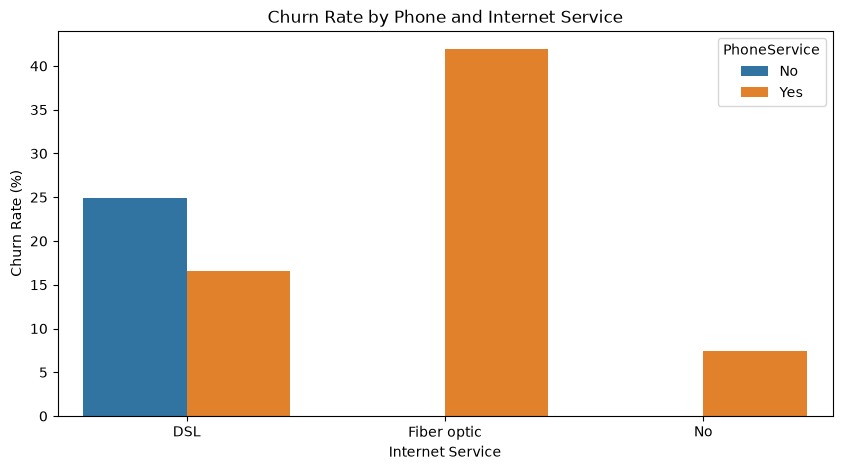

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=phone_internet_churn.reset_index(),
    x="InternetService",
    y="Yes",
    hue="PhoneService"
)

plt.title("Churn Rate by Phone and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [59]:
multiplelines_churn = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

print(multiplelines_churn)

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896


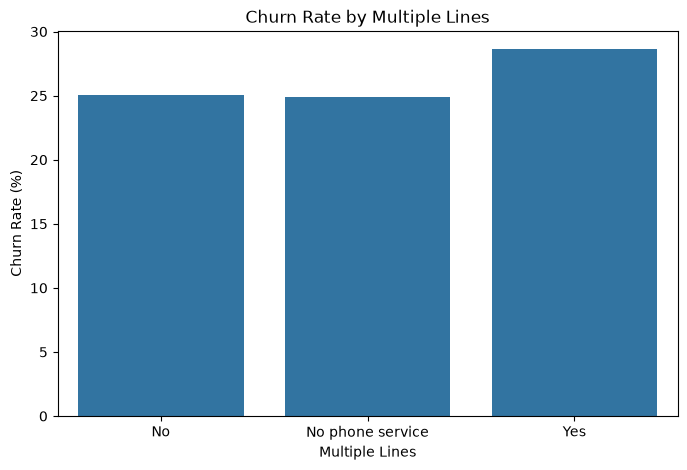

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=multiplelines_churn.reset_index(),
    x="MultipleLines",
    y="Yes"
)

plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.show()

In [61]:
contract_paperless_churn = pd.crosstab(
    [df["Contract"], df["PaperlessBilling"]],
    df["Churn"],
    normalize="index"
) * 100

print(contract_paperless_churn)

Churn                                   No        Yes
Contract       PaperlessBilling                      
Month-to-month No                68.502715  31.497285
               Yes               51.701469  48.298531
One year       No                92.867756   7.132244
               Yes               85.250000  14.750000
Two year       No                98.351648   1.648352
               Yes               95.796178   4.203822


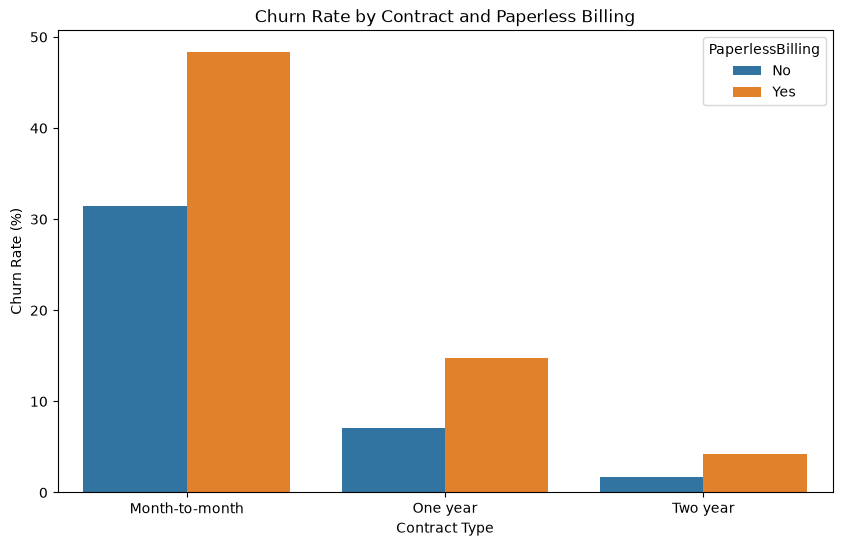

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=contract_paperless_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="PaperlessBilling"
)

plt.title("Churn Rate by Contract and Paperless Billing")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [63]:
contract_tenure_churn = pd.crosstab(
    [df["Contract"], df["tenure_group"]],
    df["Churn"],
    normalize="index"
) * 100

print(contract_tenure_churn)

Churn                                No        Yes
Contract       tenure_group                       
Month-to-month 0-12 months    48.645938  51.354062
               13-24 months   62.279512  37.720488
               25-48 months   67.082294  32.917706
               49+ months     73.976608  26.023392
One year       0-12 months    89.516129  10.483871
               13-24 months   91.878173   8.121827
               25-48 months   89.382239  10.617761
               49+ months     87.066246  12.933754
Two year       0-12 months   100.000000   0.000000
               13-24 months  100.000000   0.000000
               25-48 months   97.810219   2.189781
               49+ months     96.674584   3.325416


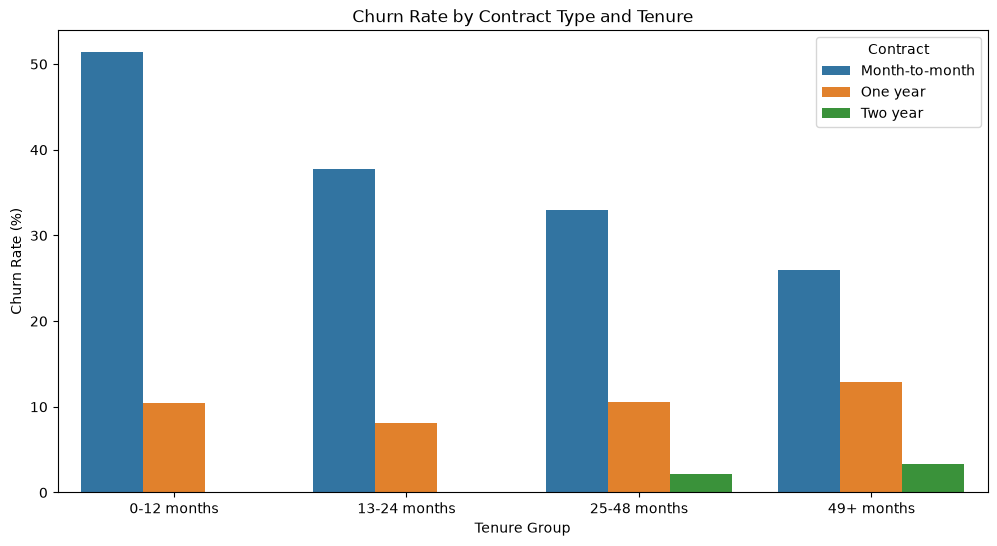

In [64]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=contract_tenure_churn.reset_index(),
    x="tenure_group",
    y="Yes",
    hue="Contract"
)

plt.title("Churn Rate by Contract Type and Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [65]:
dependents_contract_churn = pd.crosstab(
    [df["Contract"], df["Dependents"]],
    df["Churn"],
    normalize="index"
) * 100

print(dependents_contract_churn)

Churn                             No        Yes
Contract       Dependents                      
Month-to-month No          54.763448  45.236552
               Yes         67.173638  32.826362
One year       No          87.579618  12.420382
               Yes         90.772128   9.227872
Two year       No          96.685083   3.314917
               Yes         97.721519   2.278481


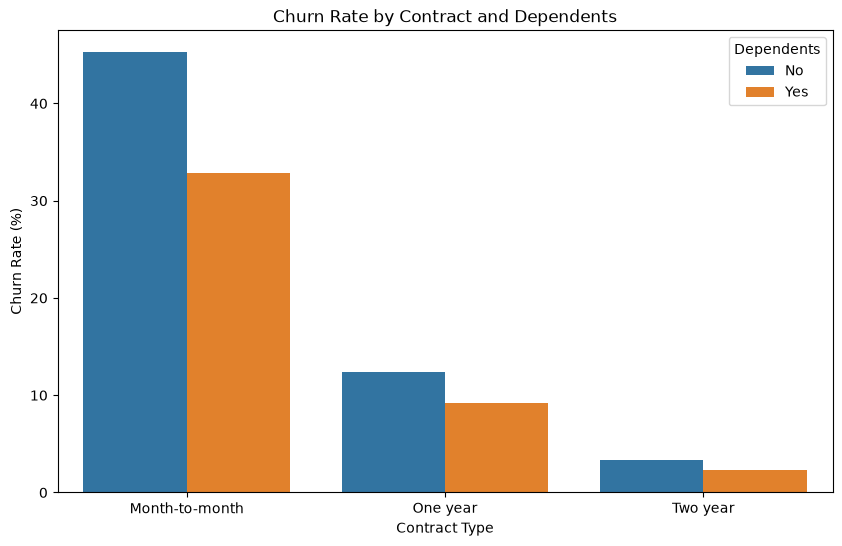

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dependents_contract_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="Dependents"
)

plt.title("Churn Rate by Contract and Dependents")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [67]:
family_churn = pd.crosstab(
    [df["Partner"], df["Dependents"]],
    df["Churn"],
    normalize="index"
) * 100

print(family_churn)

Churn                      No        Yes
Partner Dependents                      
No      No          65.762195  34.237805
        Yes         78.670360  21.329640
Yes     No          74.591652  25.408348
        Yes         85.763293  14.236707


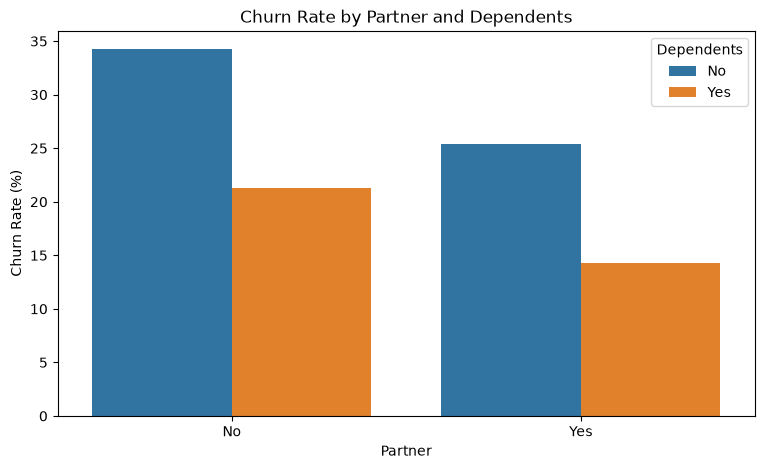

In [68]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=family_churn.reset_index(),
    x="Partner",
    y="Yes",
    hue="Dependents"
)

plt.title("Churn Rate by Partner and Dependents")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.show()

In [69]:
internet_contract_churn = pd.crosstab(
    [df["InternetService"], df["Contract"]],
    df["Churn"],
    normalize="index"
) * 100

print(internet_contract_churn)

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699


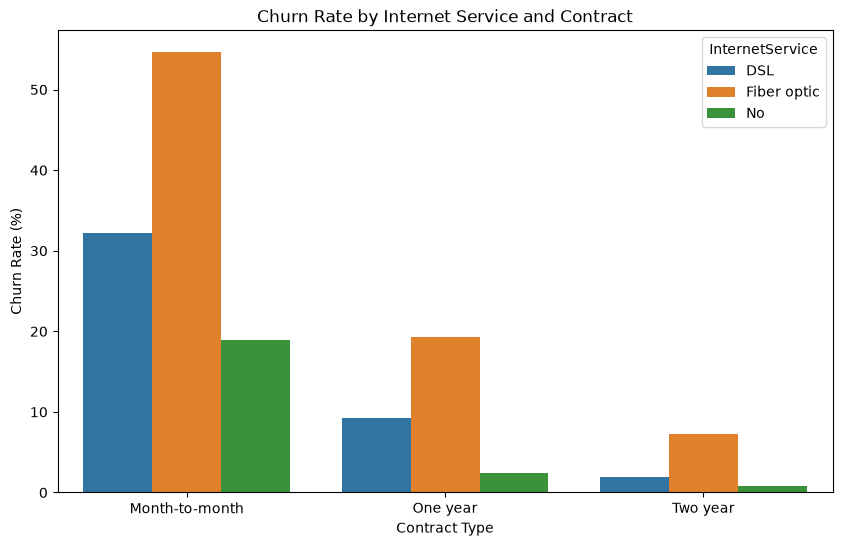

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=internet_contract_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="InternetService"
)

plt.title("Churn Rate by Internet Service and Contract")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [71]:
payment_contract_churn = pd.crosstab(
    [df["Contract"], df["PaymentMethod"]],
    df["Churn"],
    normalize="index"
) * 100

print(payment_contract_churn)

Churn                                            No        Yes
Contract       PaymentMethod                                  
Month-to-month Bank transfer (automatic)  65.874363  34.125637
               Credit card (automatic)    67.219153  32.780847
               Electronic check           46.270270  53.729730
               Mailed check               68.421053  31.578947
One year       Bank transfer (automatic)  90.281330   9.718670
               Credit card (automatic)    89.698492  10.301508
               Electronic check           81.556196  18.443804
               Mailed check               93.175074   6.824926
Two year       Bank transfer (automatic)  96.631206   3.368794
               Credit card (automatic)    97.762478   2.237522
               Electronic check           92.261905   7.738095
               Mailed check               99.214660   0.785340


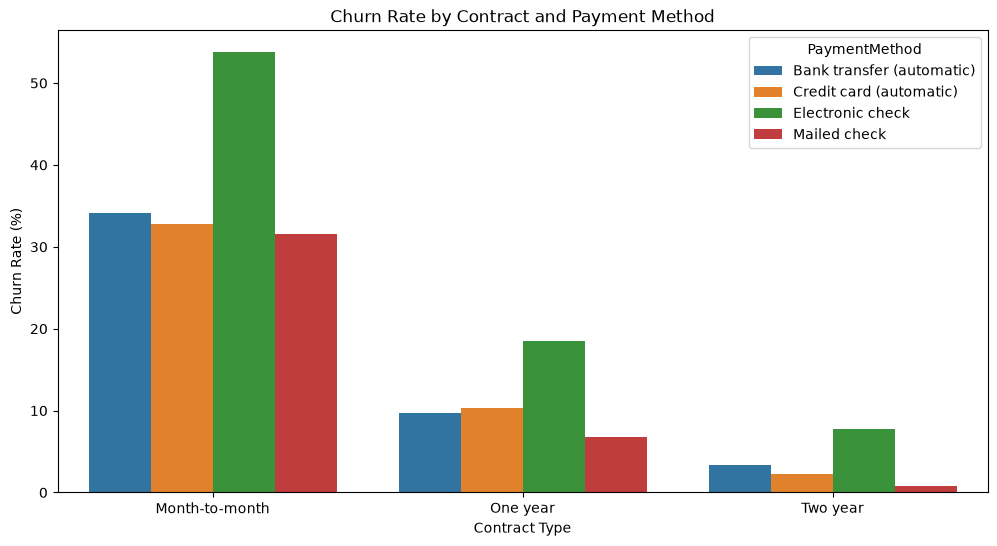

In [72]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=payment_contract_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="PaymentMethod"
)

plt.title("Churn Rate by Contract and Payment Method")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

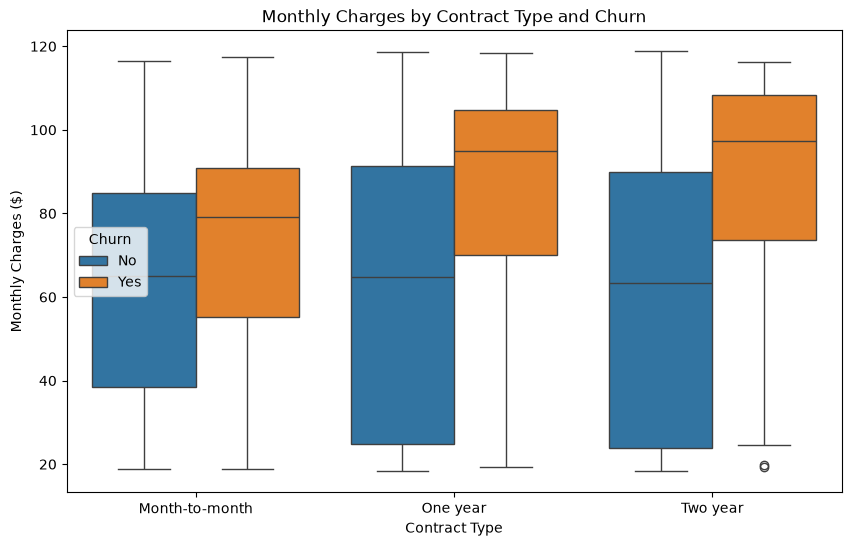

In [73]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges by Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges ($)")
plt.show()

In [74]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


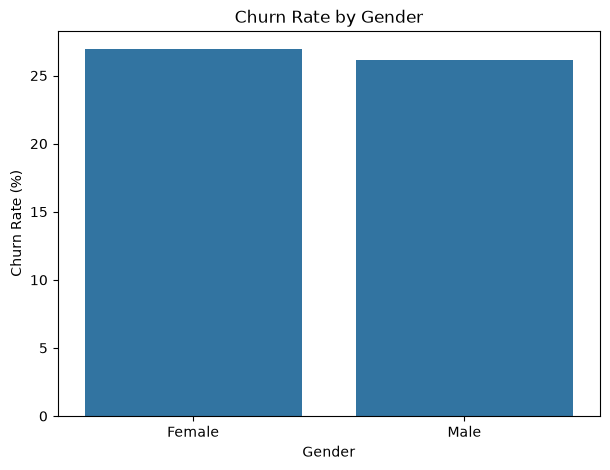

In [75]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn.reset_index(),
    x="gender",
    y="Yes"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

In [76]:
phone_lines_churn = pd.crosstab(
    [df["PhoneService"], df["MultipleLines"]],
    df["Churn"],
    normalize="index"
) * 100

print(phone_lines_churn)

Churn                                 No        Yes
PhoneService MultipleLines                         
No           No phone service  75.073314  24.926686
Yes          No                74.955752  25.044248
             Yes               71.390104  28.609896


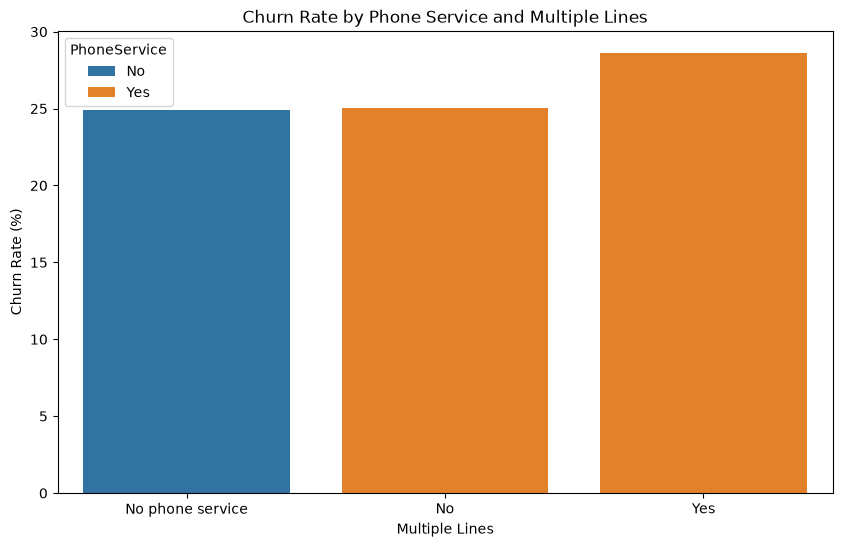

In [77]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=phone_lines_churn.reset_index(),
    x="MultipleLines",
    y="Yes",
    hue="PhoneService"
)

plt.title("Churn Rate by Phone Service and Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.show()

In [78]:
senior_contract_churn = pd.crosstab(
    [df["Contract"], df["SeniorCitizen"]],
    df["Churn"],
    normalize="index"
) * 100

print(senior_contract_churn)

Churn                                No        Yes
Contract       SeniorCitizen                      
Month-to-month 0              60.430248  39.569752
               1              45.353160  54.646840
One year       0              89.321902  10.678098
               1              84.736842  15.263158
Two year       0              97.290323   2.709677
               1              95.862069   4.137931


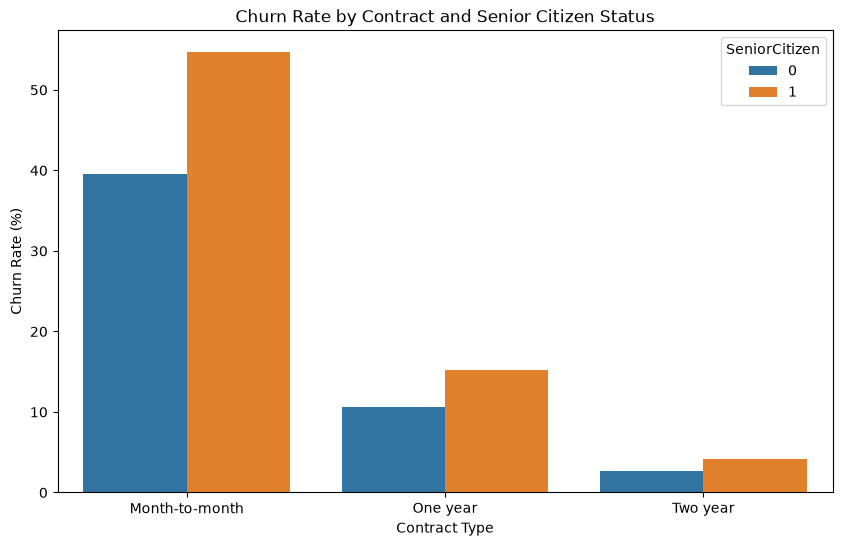

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=senior_contract_churn.reset_index(),
    x="Contract",
    y="Yes",
    hue="SeniorCitizen"
)

plt.title("Churn Rate by Contract and Senior Citizen Status")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [80]:
contract_charge_churn = pd.crosstab(
    [df["Contract"], df["monthly_charge_group"]],
    df["Churn"],
    normalize="index"
) * 100

print(contract_charge_churn)

Churn                                       No        Yes
Contract       monthly_charge_group                      
Month-to-month Below $35             75.706215  24.293785
               $35-$70               64.672897  35.327103
               $70-$100              46.813311  53.186689
               $100+                 50.000000  50.000000
One year       Below $35             96.883117   3.116883
               $35-$70               92.183288   7.816712
               $70-$100              87.162162  12.837838
               $100+                 75.091575  24.908425
Two year       Below $35             99.221184   0.778816
               $35-$70               97.887324   2.112676
               $70-$100              96.982759   3.017241
               $100+                 92.459016   7.540984


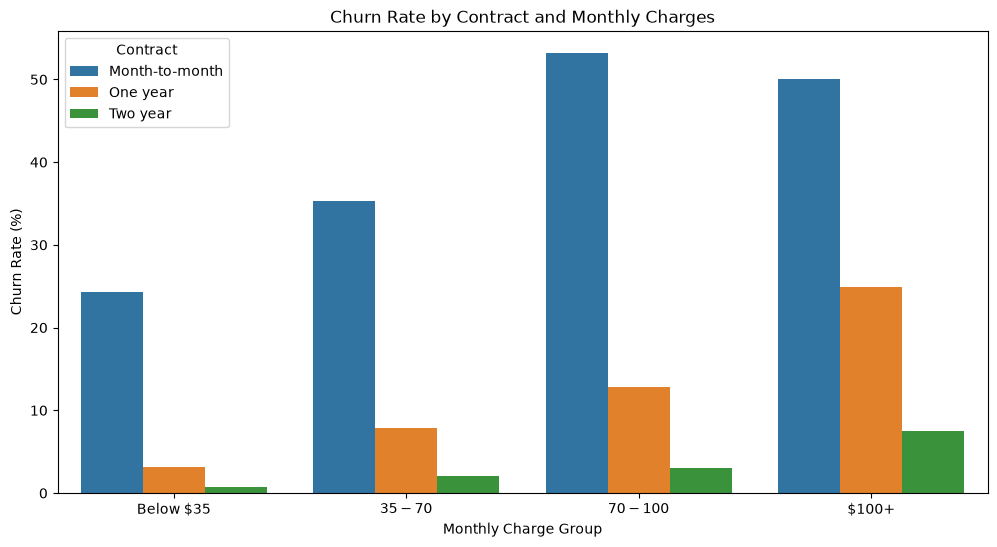

In [81]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=contract_charge_churn.reset_index(),
    x="monthly_charge_group",
    y="Yes",
    hue="Contract"
)

plt.title("Churn Rate by Contract and Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [82]:
tenure_charge_churn = pd.crosstab(
    [df["tenure_group"], df["monthly_charge_group"]],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_charge_churn)

Churn                                     No        Yes
tenure_group monthly_charge_group                      
0-12 months  Below $35             76.287051  23.712949
             $35-$70               56.567164  43.432836
             $70-$100              32.645631  67.354369
             $100+                 23.529412  76.470588
13-24 months Below $35             94.464945   5.535055
             $35-$70               77.818182  22.181818
             $70-$100              55.952381  44.047619
             $100+                 43.103448  56.896552
25-48 months Below $35             95.721925   4.278075
             $35-$70               89.501312  10.498688
             $70-$100              69.462025  30.537975
             $100+                 63.285024  36.714976
49+ months   Below $35             98.663697   1.336303
             $35-$70               94.736842   5.263158
             $70-$100              89.937888  10.062112
             $100+                 82.081911  17

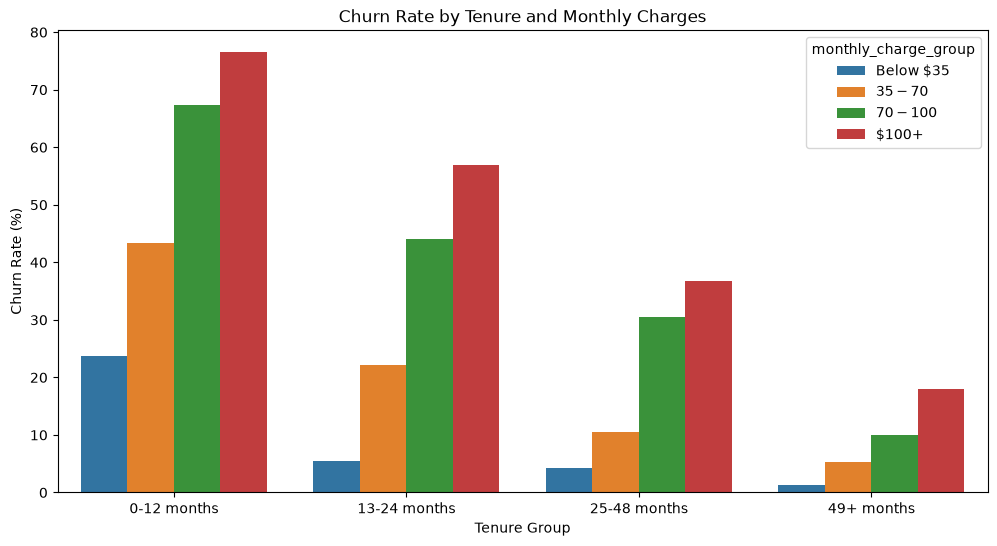

In [83]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=tenure_charge_churn.reset_index(),
    x="tenure_group",
    y="Yes",
    hue="monthly_charge_group"
)

plt.title("Churn Rate by Tenure and Monthly Charges")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [84]:
heatmap_data = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
) * 100

print(heatmap_data)

InternetService        DSL  Fiber optic         No
Contract                                          
Month-to-month   32.215863    54.605263  18.893130
One year          9.298246    19.294991   2.472527
Two year          1.910828     7.226107   0.783699


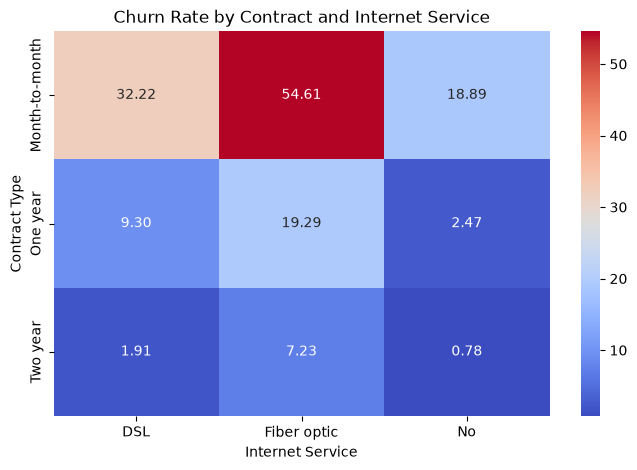

In [85]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")
plt.show()

In [86]:
payment_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="PaymentMethod",
    aggfunc="mean"
) * 100

print(payment_heatmap)

PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Contract                                                             
Month-to-month                  34.125637                32.780847   
One year                         9.718670                10.301508   
Two year                         3.368794                 2.237522   

PaymentMethod   Electronic check  Mailed check  
Contract                                        
Month-to-month         53.729730     31.578947  
One year               18.443804      6.824926  
Two year                7.738095      0.785340  


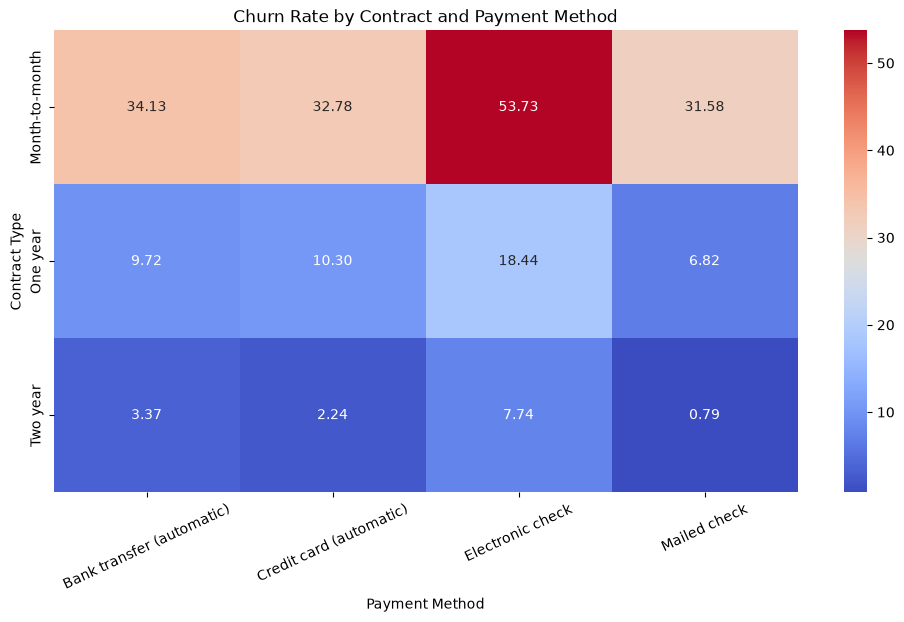

In [87]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    payment_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Contract Type")
plt.xticks(rotation=25)
plt.show()

In [88]:
paperless_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="PaperlessBilling",
    aggfunc="mean"
) * 100

print(paperless_heatmap)

PaperlessBilling         No        Yes
Contract                              
Month-to-month    31.497285  48.298531
One year           7.132244  14.750000
Two year           1.648352   4.203822


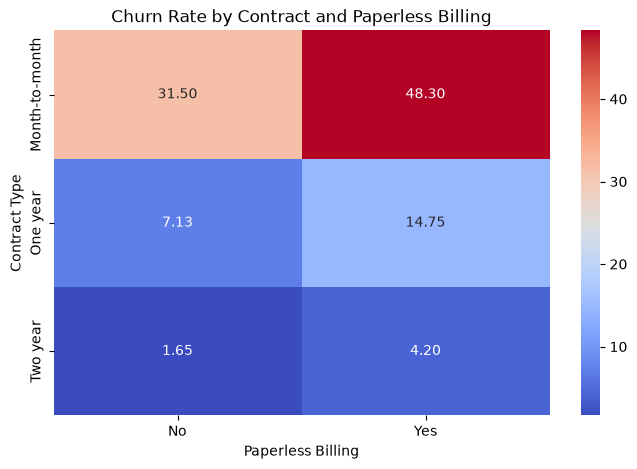

In [89]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    paperless_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Contract Type")
plt.show()

In [90]:
senior_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="SeniorCitizen",
    aggfunc="mean"
) * 100

print(senior_heatmap)

SeniorCitizen           0          1
Contract                            
Month-to-month  39.569752  54.646840
One year        10.678098  15.263158
Two year         2.709677   4.137931


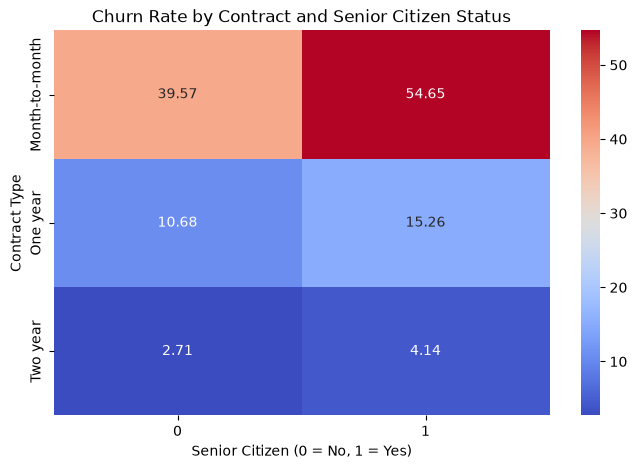

In [91]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    senior_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Contract Type")
plt.show()

In [92]:
dependents_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="Dependents",
    aggfunc="mean"
) * 100

print(dependents_heatmap)

Dependents             No        Yes
Contract                            
Month-to-month  45.236552  32.826362
One year        12.420382   9.227872
Two year         3.314917   2.278481


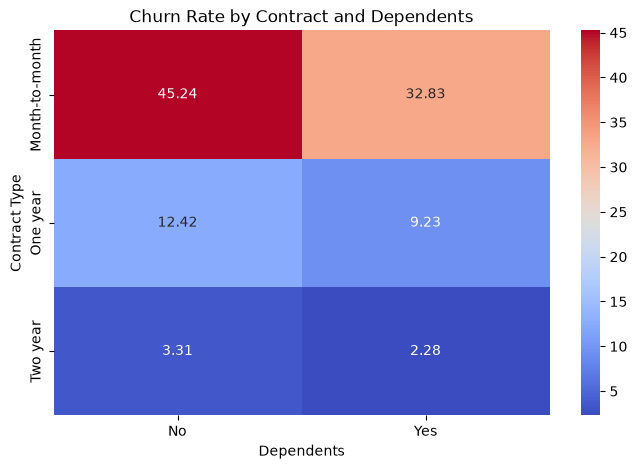

In [93]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    dependents_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Dependents")
plt.xlabel("Dependents")
plt.ylabel("Contract Type")
plt.show()

In [94]:
partner_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="Contract",
    columns="Partner",
    aggfunc="mean"
) * 100

print(partner_heatmap)

Partner                No        Yes
Contract                            
Month-to-month  44.689379  39.130435
One year        10.575428  11.807229
Two year         3.379722   2.600671


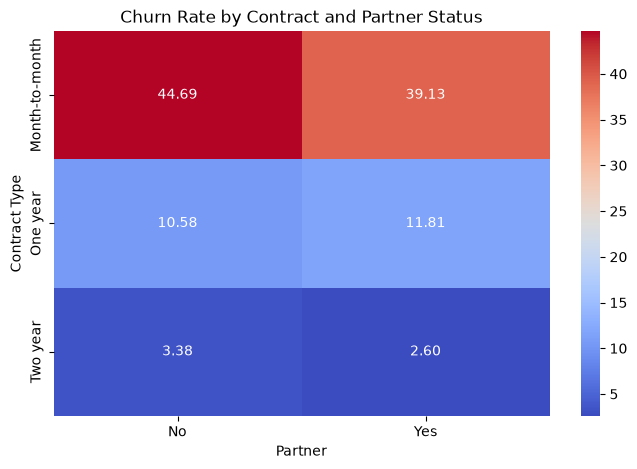

In [95]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    partner_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Contract and Partner Status")
plt.xlabel("Partner")
plt.ylabel("Contract Type")
plt.show()

In [96]:
service_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="service_count",
    aggfunc="mean"
) * 100

print(service_heatmap)

               Churn_numeric
service_count               
0                  21.406039
1                  45.755694
2                  35.818006
3                  27.370304
4                  22.300469
5                  12.434326
6                   5.281690


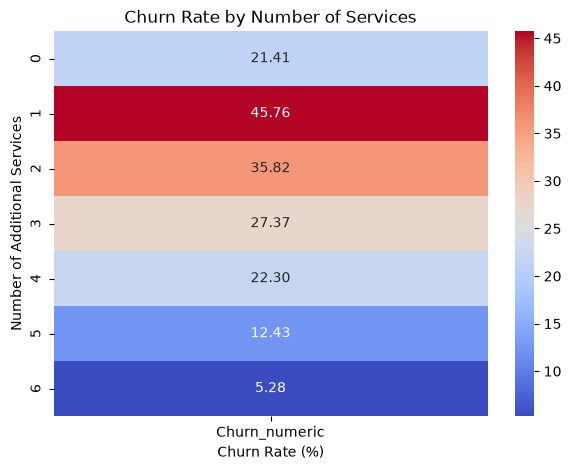

In [97]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    service_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Number of Additional Services")
plt.show()

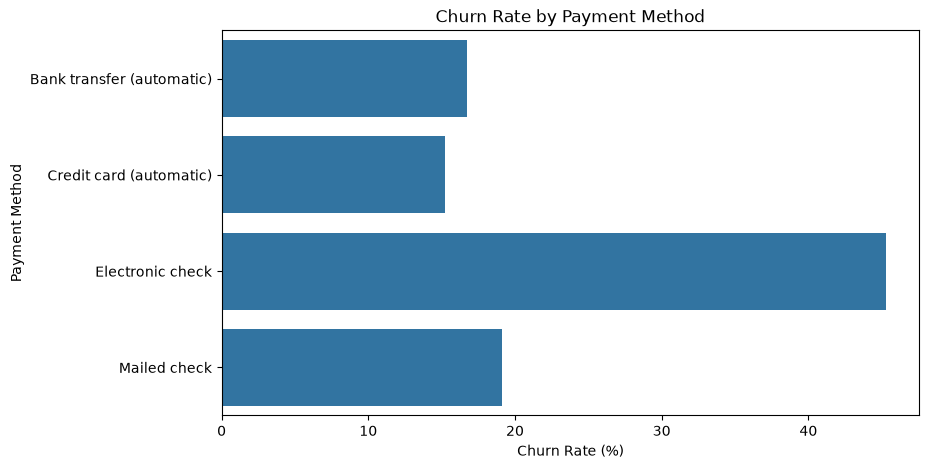

In [98]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_churn.reset_index(),
    x="Yes",
    y="PaymentMethod"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.show()

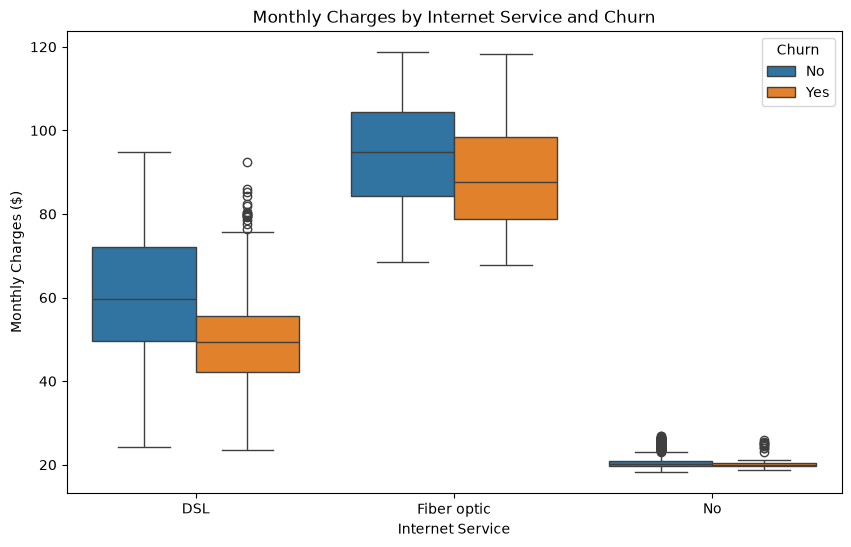

In [99]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="InternetService",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges by Internet Service and Churn")
plt.xlabel("Internet Service")
plt.ylabel("Monthly Charges ($)")
plt.show()

Contract      Month-to-month   One year  Two year
tenure_group                                     
0-12 months        51.354062  10.483871  0.000000
13-24 months       37.720488   8.121827  0.000000
25-48 months       32.917706  10.617761  2.189781
49+ months         26.023392  12.933754  3.325416


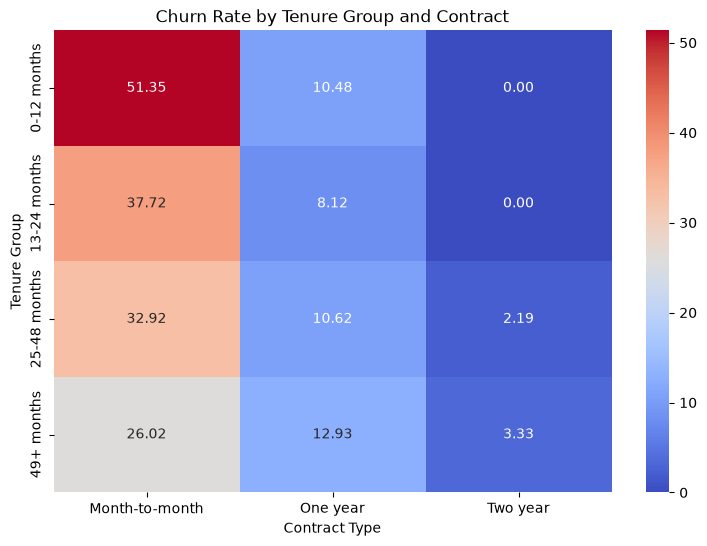

In [100]:
tenure_contract_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="tenure_group",
    columns="Contract",
    aggfunc="mean"
) * 100

print(tenure_contract_heatmap)
plt.figure(figsize=(9, 6))

sns.heatmap(
    tenure_contract_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Tenure Group and Contract")
plt.xlabel("Contract Type")
plt.ylabel("Tenure Group")
plt.show()

InternetService        DSL  Fiber optic         No
tenure_group                                      
0-12 months      40.000000    69.880823  17.933723
13-24 months     19.642857    48.775056   3.765690
25-48 months     10.786106    36.619718   1.780415
49+ months        4.314721    17.061144   1.372998


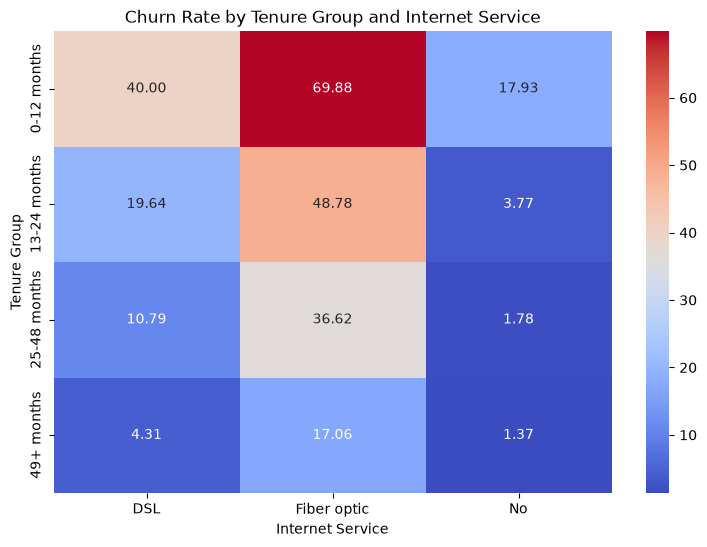

In [101]:
tenure_internet_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="tenure_group",
    columns="InternetService",
    aggfunc="mean"
) * 100

print(tenure_internet_heatmap)
plt.figure(figsize=(9, 6))

sns.heatmap(
    tenure_internet_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Tenure Group and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Tenure Group")
plt.show()

PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
tenure_group                                                        
0-12 months                    44.978166                36.000000   
13-24 months                   22.033898                23.204420   
25-48 months                   15.957447                15.831135   
49+ months                      7.349081                 6.648575   

PaymentMethod  Electronic check  Mailed check  
tenure_group                                   
0-12 months           61.963190     32.758621  
13-24 months          48.421053     10.139860  
25-48 months          33.846154      9.090909  
49+ months            21.560575      1.185771  


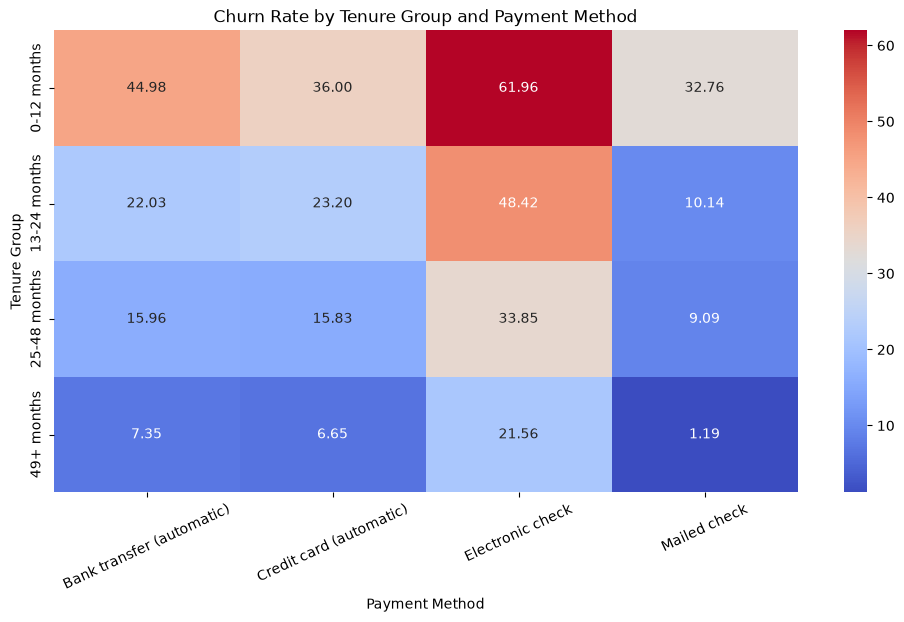

In [102]:
tenure_payment_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="tenure_group",
    columns="PaymentMethod",
    aggfunc="mean"
) * 100

print(tenure_payment_heatmap)
plt.figure(figsize=(12, 6))

sns.heatmap(
    tenure_payment_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Tenure Group and Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Tenure Group")
plt.xticks(rotation=25)
plt.show()

PaperlessBilling         No        Yes
tenure_group                          
0-12 months       33.111111  57.465008
13-24 months      13.801453  38.788871
25-48 months       9.741248  27.854856
49+ months         5.543237  12.191473


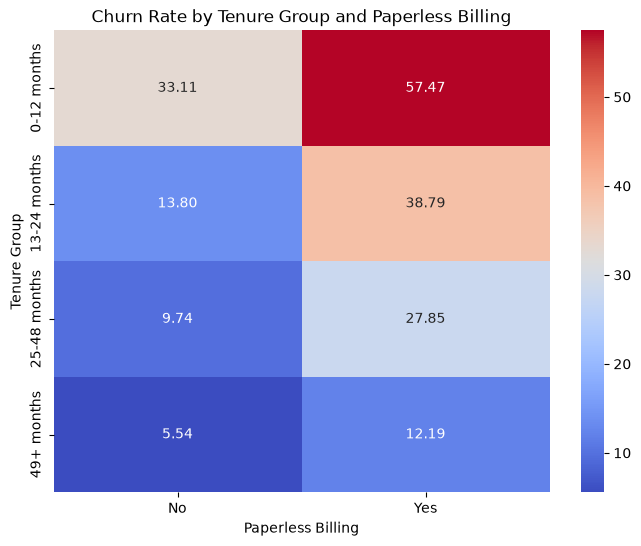

In [103]:
tenure_paperless_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="tenure_group",
    columns="PaperlessBilling",
    aggfunc="mean"
) * 100

print(tenure_paperless_heatmap)
plt.figure(figsize=(8, 6))

sns.heatmap(
    tenure_paperless_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Tenure Group and Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Tenure Group")
plt.show()

InternetService             DSL  Fiber optic       No
monthly_charge_group                                 
Below $35             36.363636          NaN  7.40498
$35-$70               21.264724     62.50000      NaN
$70-$100               6.677796     46.78194      NaN
$100+                       NaN     28.04878      NaN


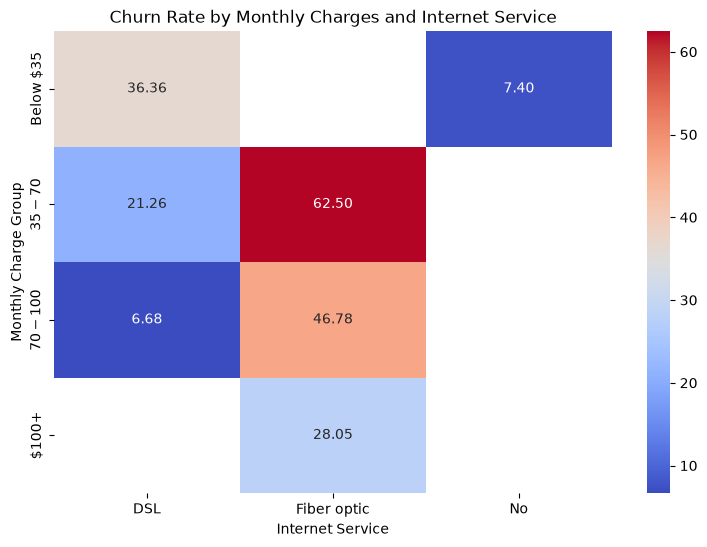

In [104]:
charge_internet_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="monthly_charge_group",
    columns="InternetService",
    aggfunc="mean"
) * 100

print(charge_internet_heatmap)

plt.figure(figsize=(9, 6))

sns.heatmap(
    charge_internet_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Monthly Charges and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Monthly Charge Group")
plt.show()

Contract              Month-to-month   One year  Two year
monthly_charge_group                                     
Below $35                  24.293785   3.116883  0.778816
$35-$70                    35.327103   7.816712  2.112676
$70-$100                   53.186689  12.837838  3.017241
$100+                      50.000000  24.908425  7.540984


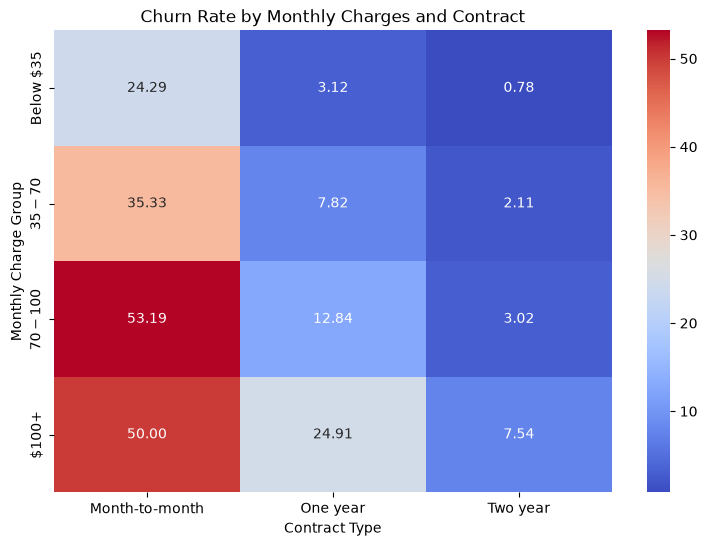

In [105]:
charge_contract_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="monthly_charge_group",
    columns="Contract",
    aggfunc="mean"
) * 100

print(charge_contract_heatmap)

plt.figure(figsize=(9, 6))

sns.heatmap(
    charge_contract_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Monthly Charges and Contract")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charge Group")
plt.show()

SeniorCitizen                 0          1
monthly_charge_group                      
Below $35             10.012136  27.586207
$35-$70               22.454308  35.751295
$70-$100              34.469328  48.803828
$100+                 26.386807  32.765957


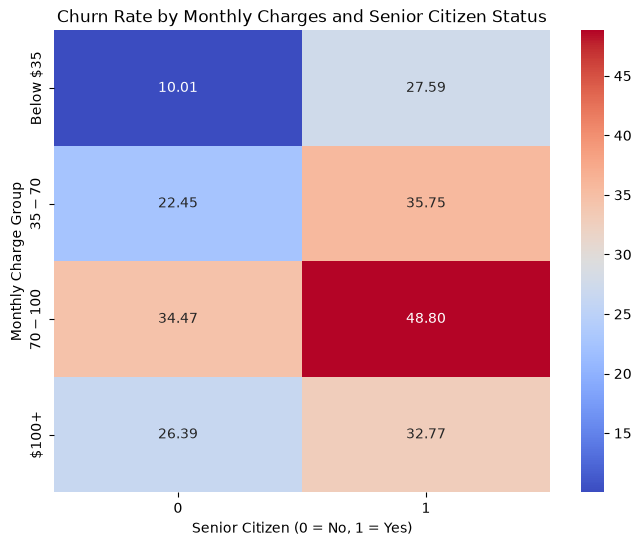

In [106]:
senior_charge_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="monthly_charge_group",
    columns="SeniorCitizen",
    aggfunc="mean"
) * 100

print(senior_charge_heatmap)
plt.figure(figsize=(8, 6))

sns.heatmap(
    senior_charge_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Monthly Charges and Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charge Group")
plt.show()

SeniorCitizen          0          1
tenure_group                       
0-12 months    43.944266  67.812500
13-24 months   24.649533  49.404762
25-48 months   15.917746  41.281139
49+ months      8.199357  16.085791


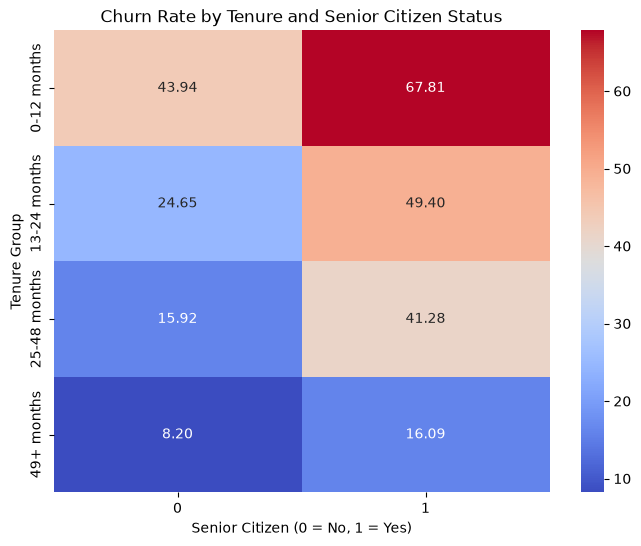

In [107]:
senior_tenure_heatmap = pd.pivot_table(
    df,
    values="Churn_numeric",
    index="tenure_group",
    columns="SeniorCitizen",
    aggfunc="mean"
) * 100

print(senior_tenure_heatmap)
plt.figure(figsize=(8, 6))

sns.heatmap(
    senior_tenure_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Churn Rate by Tenure and Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Tenure Group")
plt.show()

In [108]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
tenure_group            0
monthly_charge_group    0
Churn_numeric           0
service_count           0
dtype: int64


In [109]:
# Check blank values
print("Blank TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())

Blank TotalCharges: 11


In [110]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [111]:
# Display customers with missing TotalCharges
missing_totalcharges = df[df["TotalCharges"].isnull()]

print(missing_totalcharges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])


      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


In [112]:
print("Tenure values:")
print(missing_totalcharges["tenure"].value_counts())

Tenure values:
tenure
0    11
Name: count, dtype: int64


In [113]:
# Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after filling:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges after filling:
0


In [114]:
print("TotalCharges datatype:", df["TotalCharges"].dtype)

TotalCharges datatype: float64


In [115]:
# Check missing values after cleaning
missing_values = df.isnull().sum()

print(missing_values)

customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
tenure_group            0
monthly_charge_group    0
Churn_numeric           0
service_count           0
dtype: int64


In [116]:
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [117]:
# Check unique values in categorical columns

categorical_columns = df.select_dtypes(include=["str", "object"]).columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].unique())


--- customerID ---
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

--- gender ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

--- Partner ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Dependents ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- PhoneService ---
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

--- MultipleLines ---
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

--- InternetService ---
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- OnlineSecurity ---
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- OnlineBackup ---
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: s

In [118]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["str", "object"]
).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric', 'service_count']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [119]:
# Remove customerID from feature columns

df_model = df.drop(columns=["customerID"])

print("Original shape:", df.shape)
print("Model dataset shape:", df_model.shape)

Original shape: (7043, 25)
Model dataset shape: (7043, 24)


In [120]:
# Check duplicate customer IDs

duplicate_ids = df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_ids)

Duplicate customer IDs: 0


In [121]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [122]:
# Check Churn values

print(df["Churn"].unique())
print("\nChurn counts:")
print(df["Churn"].value_counts())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [123]:
# Encode Churn: No = 0, Yes = 1

df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nEncoded Churn:")
print(df_model["Churn"].value_counts())


Encoded Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [124]:
# Separate features and target

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 23)
Target shape: (7043,)


In [125]:
# Find categorical columns in X

categorical_features = X.select_dtypes(
    include=["str", "object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [126]:
# Find numerical columns in X

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)


Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric', 'service_count']


In [127]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_encoded = encoder.fit_transform(X[categorical_features])

print("Encoded shape:", X_encoded.shape)

Encoded shape: (7043, 41)


In [128]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_encoded = encoder.fit_transform(X[categorical_features])

print("Encoded shape:", X_encoded.shape)

Encoded shape: (7043, 41)


In [129]:
import numpy as np

X_numerical = X[numerical_features].to_numpy()

X_final = np.hstack([
    X_numerical,
    X_encoded
])

print("Final feature shape:", X_final.shape)

Final feature shape: (7043, 47)


In [130]:
print("Rows:", X_final.shape[0])
print("Features:", X_final.shape[1])

print("Missing values:", np.isnan(X_final).sum())

Rows: 7043
Features: 47
Missing values: 0


In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 47)
X_test: (1409, 47)
y_train: (5634,)
y_test: (1409,)


In [132]:
print("Training Churn Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Churn Distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [133]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [134]:
# Make predictions
y_pred = model.predict(X_test)

print("Predictions created successfully!")
print("Number of predictions:", len(y_pred))

Predictions created successfully!
Number of predictions: 1409


In [135]:
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]


In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [137]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1035    0]
 [   0  374]]


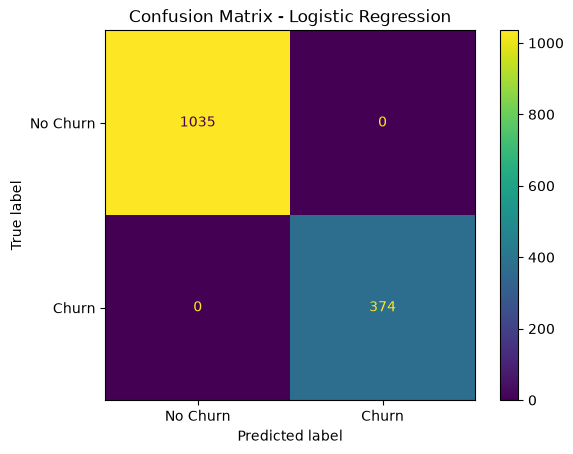

In [138]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [139]:
# Remove target and target-leakage columns

df_model = df.drop(
    columns=["customerID", "Churn", "Churn_numeric"]
)

X = df_model
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 22)
Target: (7043,)


In [140]:
categorical_features = X.select_dtypes(
    include=["str", "object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'service_count']


In [141]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train_raw.shape)
print("Testing data:", X_test_raw.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (5634, 22)
Testing data: (1409, 22)
Training target: (5634,)
Testing target: (1409,)


In [142]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Encoded training shape:", X_train.shape)
print("Encoded testing shape:", X_test.shape)

Encoded training shape: (5634, 46)
Encoded testing shape: (1409, 46)


In [143]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\YOGISHWAR\Desktop\customer-churn-ltv-engine\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [144]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [145]:
# Make predictions
y_pred = model.predict(X_test)

print("Predictions created successfully!")
print("Number of predictions:", len(y_pred))

Predictions created successfully!
Number of predictions: 1409


In [146]:
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.807
Precision: 0.6594
Recall   : 0.5642
F1 Score : 0.6081


In [148]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[926 109]
 [163 211]]


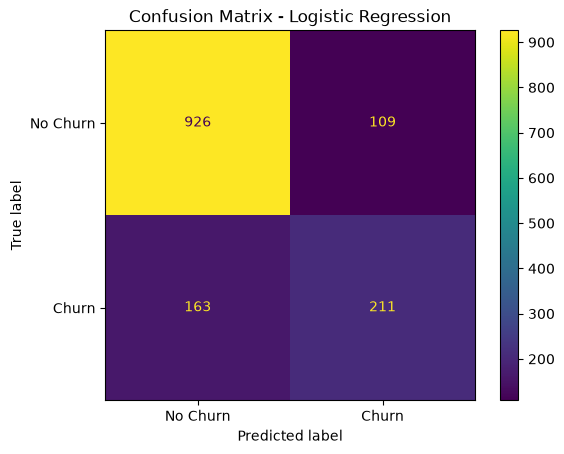

In [149]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [150]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [151]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.659375, 'Recall': 0.5641711229946524, 'F1 Score': 0.6080691642651297}


In [152]:
results_df = pd.DataFrame([baseline_results])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.806955   0.659375  0.564171  0.608069


In [153]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [154]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [155]:
# Make Random Forest predictions

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions created successfully!")
print("Number of predictions:", len(rf_pred))

Random Forest predictions created successfully!
Number of predictions: 1409


In [156]:
print("First 20 predictions:")
print(rf_pred[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [157]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
Accuracy : 0.7665
Precision: 0.5522
Recall   : 0.6364
F1 Score : 0.5913


Random Forest Confusion Matrix:
[[842 193]
 [136 238]]


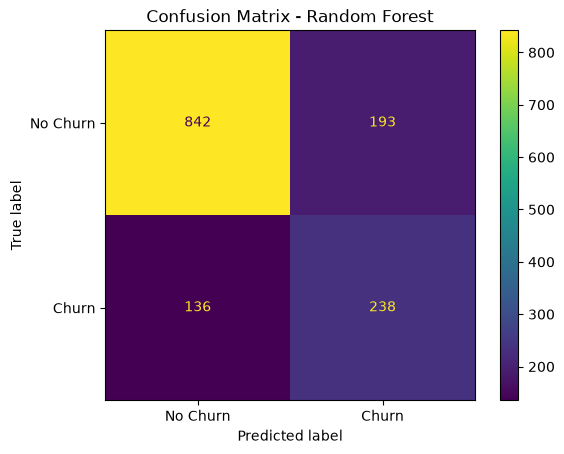

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No Churn", "Churn"]
)

rf_disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [159]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [160]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
}

results_df = pd.concat(
    [results_df, pd.DataFrame([rf_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.659375,0.564171,0.608069
1,Random Forest,0.766501,0.552204,0.636364,0.591304


In [161]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
44,numerical__TotalCharges,0.141053
42,numerical__tenure,0.125612
43,numerical__MonthlyCharges,0.120936
32,categorical__Contract_Month-to-month,0.071682
14,categorical__OnlineSecurity_No,0.034836
34,categorical__Contract_Two year,0.032492
23,categorical__TechSupport_No,0.031686
39,categorical__PaymentMethod_Electronic check,0.028613
12,categorical__InternetService_Fiber optic,0.028462
45,numerical__service_count,0.027829


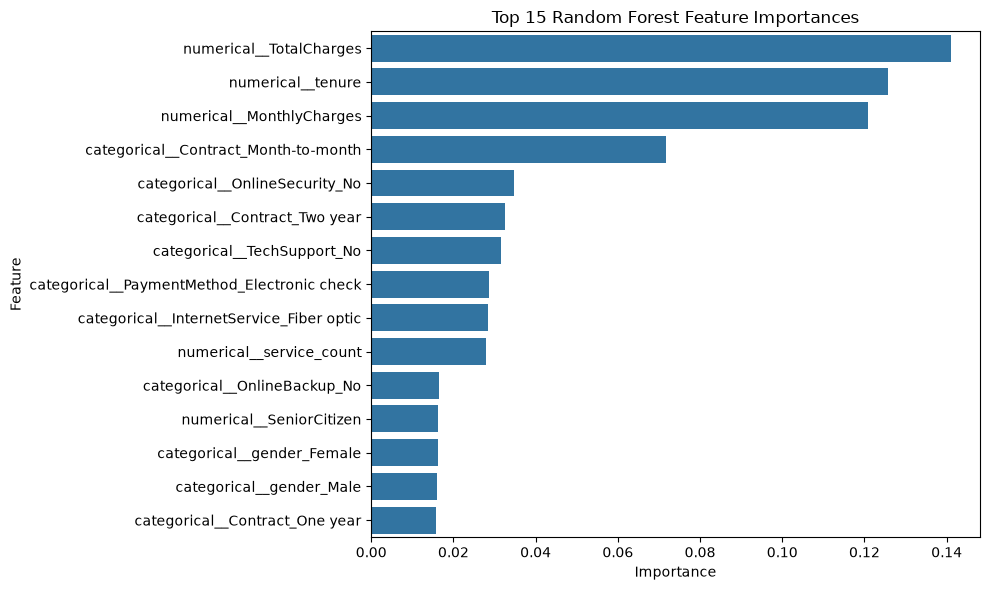

In [162]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [163]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [164]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall   :", xgb_recall)
print("XGBoost F1 Score :", xgb_f1)

XGBoost Accuracy : 0.8026969481902059
XGBoost Precision: 0.66
XGBoost Recall   : 0.5294117647058824
XGBoost F1 Score : 0.5875370919881305


In [166]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1
}

results_df = pd.concat(
    [results_df, pd.DataFrame([xgb_results])],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.659375,0.564171,0.608069
1,Random Forest,0.766501,0.552204,0.636364,0.591304
2,XGBoost,0.802697,0.660000,0.529412,0.587537


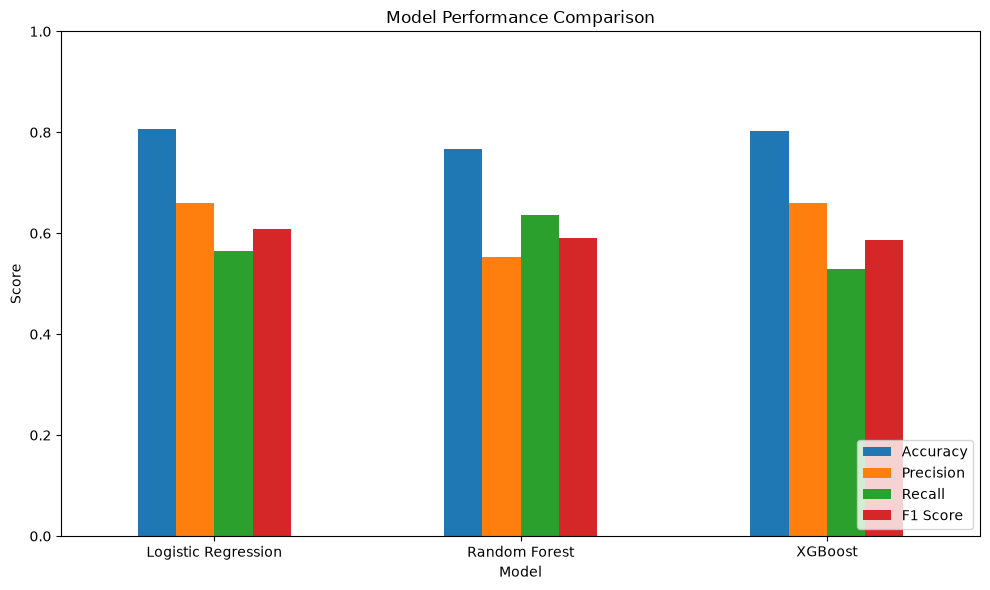

In [167]:
results_plot = results_df.copy()

results_plot = results_plot.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [168]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [169]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 46)


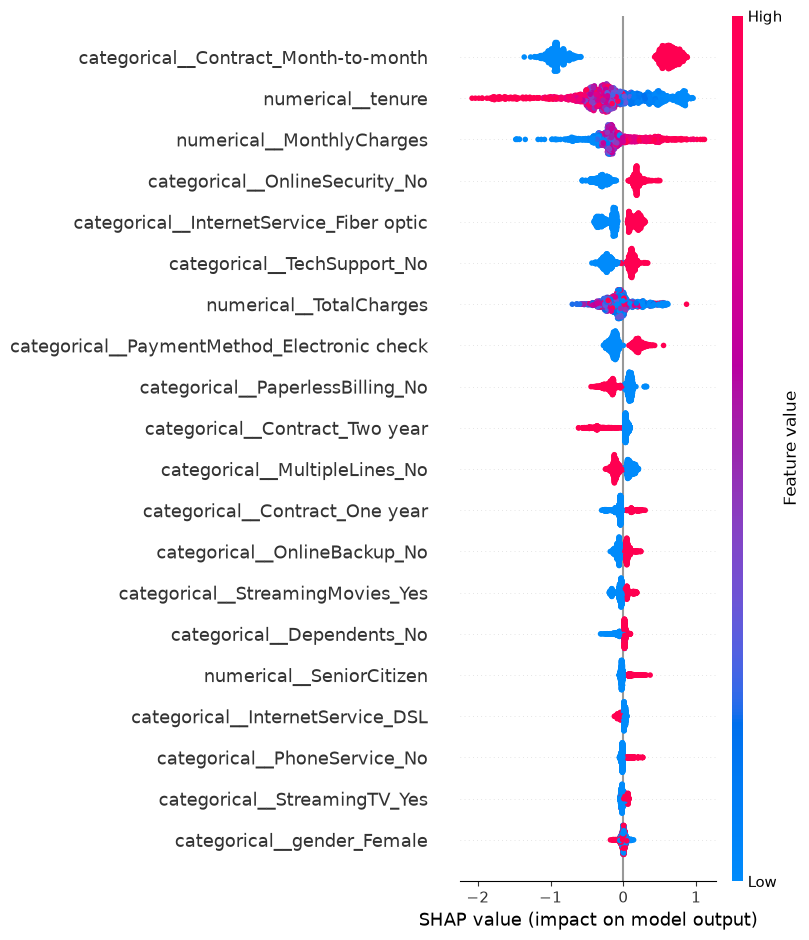

In [170]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)

In [171]:
customer_index = 0

print("Actual Churn:", y_test.iloc[customer_index])
print("Predicted Churn:", xgb_pred[customer_index])

Actual Churn: 0
Predicted Churn: 0


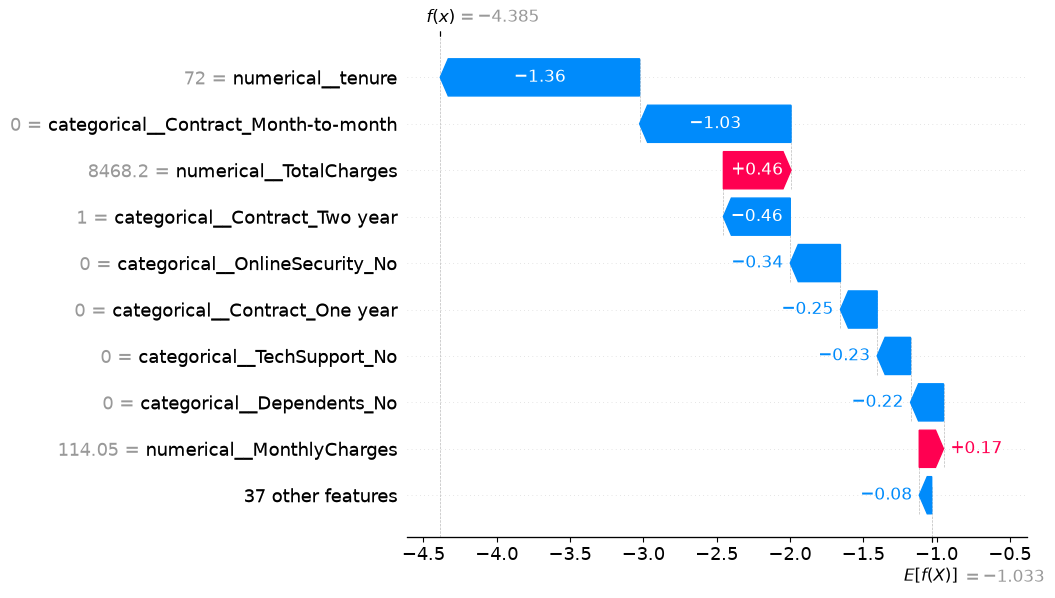

In [172]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_test[customer_index],
        feature_names=feature_names
    )
)

In [173]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 25


In [174]:
df.isnull().sum()

customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
tenure_group            0
monthly_charge_group    0
Churn_numeric           0
service_count           0
dtype: int64

In [175]:
df.dtypes

customerID                   str
gender                       str
SeniorCitizen              int64
Partner                      str
Dependents                   str
tenure                     int64
PhoneService                 str
MultipleLines                str
InternetService              str
OnlineSecurity               str
OnlineBackup                 str
DeviceProtection             str
TechSupport                  str
StreamingTV                  str
StreamingMovies              str
Contract                     str
PaperlessBilling             str
PaymentMethod                str
MonthlyCharges           float64
TotalCharges             float64
Churn                        str
tenure_group            category
monthly_charge_group    category
Churn_numeric              int64
service_count              int64
dtype: object

In [176]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [177]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

C:\Users\YOGISHWAR\AppData\Local\Temp\ipykernel_9232\358977919.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [178]:
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [179]:
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [180]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())
print("Zero TotalCharges:", (df["TotalCharges"] == 0).sum())

TotalCharges dtype: float64
Missing TotalCharges: 0
Zero TotalCharges: 11


In [181]:
categorical_columns = df.select_dtypes(include=["object", "str"]).columns.tolist()

print("Number of categorical columns:", len(categorical_columns))
print("\nCategorical columns:")
for col in categorical_columns:
    print("-", col)

Number of categorical columns: 17

Categorical columns:
- customerID
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- Churn


In [182]:
print("Original features:", X_train_raw.shape[1])
print("Encoded features:", X_train.shape[1])

Original features: 22
Encoded features: 46


In [183]:
feature_names = preprocessor.get_feature_names_out()

print("Total encoded features:", len(feature_names))
print("\nEncoded features:")
for feature in feature_names:
    print(feature)

Total encoded features: 46

Encoded features:
categorical__gender_Female
categorical__gender_Male
categorical__Partner_No
categorical__Partner_Yes
categorical__Dependents_No
categorical__Dependents_Yes
categorical__PhoneService_No
categorical__PhoneService_Yes
categorical__MultipleLines_No
categorical__MultipleLines_No phone service
categorical__MultipleLines_Yes
categorical__InternetService_DSL
categorical__InternetService_Fiber optic
categorical__InternetService_No
categorical__OnlineSecurity_No
categorical__OnlineSecurity_No internet service
categorical__OnlineSecurity_Yes
categorical__OnlineBackup_No
categorical__OnlineBackup_No internet service
categorical__OnlineBackup_Yes
categorical__DeviceProtection_No
categorical__DeviceProtection_No internet service
categorical__DeviceProtection_Yes
categorical__TechSupport_No
categorical__TechSupport_No internet service
categorical__TechSupport_Yes
categorical__StreamingTV_No
categorical__StreamingTV_No internet service
categorical__Streami

In [184]:
print("Target columns in X:")

for col in ["Churn", "Churn_numeric"]:
    print(col, "→", col in X.columns)

Target columns in X:
Churn → False
Churn_numeric → False


## Data Cleaning & Preprocessing Summary

- Dataset contains 7,043 customer records.
- `TotalCharges` was originally stored as a string because of blank values.
- Blank `TotalCharges` values were converted to numeric `NaN` and filled with `0`.
- After cleaning, no missing values remain in the dataframe.
- `customerID` was excluded from model features because it is an identifier.
- `Churn` was excluded from the input features and used as the target variable.
- `Churn_numeric` was also excluded from model features to prevent data leakage.
- Categorical variables were converted into numerical features using One-Hot Encoding.
- Numerical features were passed through without encoding.
- The preprocessing pipeline was fitted only on the training data and then applied to the test data.
- The preprocessing step produced 46 encoded features from the original 22 model input features.

## Week 2 - Feature Engineering

In [185]:
# Create a copy for feature engineering
df_features = df.copy()

# 1. Average Monthly Revenue
df_features["AverageMonthlyRevenue"] = (
    df_features["TotalCharges"] /
    df_features["tenure"].replace(0, 1)
)

# 2. Is the customer on a long-term contract?
df_features["IsLongTermContract"] = (
    df_features["Contract"] != "Month-to-month"
).astype(int)

# 3. Is the customer a new customer?
df_features["IsNewCustomer"] = (
    df_features["tenure"] <= 12
).astype(int)

# 4. High monthly charges
df_features["HighMonthlyCharges"] = (
    df_features["MonthlyCharges"] > 70
).astype(int)

# Display new features
df_features[
    [
        "AverageMonthlyRevenue",
        "IsLongTermContract",
        "IsNewCustomer",
        "HighMonthlyCharges"
    ]
].head()

,AverageMonthlyRevenue,IsLongTermContract,IsNewCustomer,HighMonthlyCharges
0,29.850000,0,1,0
1,55.573529,1,0,0
2,54.075000,0,1,0
3,40.905556,1,0,0
4,75.825000,0,1,1


In [186]:
# Check new feature information
print("New Features Summary:")
print(df_features[
    [
        "AverageMonthlyRevenue",
        "IsLongTermContract",
        "IsNewCustomer",
        "HighMonthlyCharges"
    ]
].describe())

New Features Summary:
       AverageMonthlyRevenue  IsLongTermContract  IsNewCustomer  \
count            7043.000000         7043.000000    7043.000000   
mean               64.698218            0.449808       0.310379   
std                30.270670            0.497510       0.462682   
min                 0.000000            0.000000       0.000000   
25%                35.649000            0.000000       0.000000   
50%                70.300000            0.000000       0.000000   
75%                90.174158            1.000000       1.000000   
max               121.400000            1.000000       1.000000   

       HighMonthlyCharges  
count         7043.000000  
mean             0.508732  
std              0.499959  
min              0.000000  
25%              0.000000  
50%              1.000000  
75%              1.000000  
max              1.000000  


In [187]:
# Analyze new features against churn
feature_churn_analysis = df_features.groupby("Churn")[
    [
        "AverageMonthlyRevenue",
        "IsLongTermContract",
        "IsNewCustomer",
        "HighMonthlyCharges"
    ]
].mean()

print(feature_churn_analysis)

       AverageMonthlyRevenue  IsLongTermContract  IsNewCustomer  \
Churn                                                             
No                 61.181674            0.570932       0.222072   
Yes                74.433154            0.114500       0.554842   

       HighMonthlyCharges  
Churn                      
No               0.447623  
Yes              0.677903  


## Day 8: Feature Engineering Findings

- Created four new features to capture customer behavior.
- Long-term contracts are more common among customers who did not churn.
- New customers and customers with high monthly charges show higher churn proportions.
- Feature engineering provides additional inputs for predictive modeling.

In [188]:
# Day 9: Final Data Validation

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Customer IDs:")
print(df["customerID"].duplicated().sum())

print("\nTotalCharges Data Type:")
print(df["TotalCharges"].dtype)

Dataset Shape: (7043, 25)

Missing Values:
0

Duplicate Rows:
0

Duplicate Customer IDs:
0

TotalCharges Data Type:
float64


In [189]:
# Day 9: Save Cleaned Dataset

import os

# Create processed data folder
os.makedirs("../data/processed", exist_ok=True)

# Save cleaned dataset
df.to_csv(
    "../data/processed/cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)

Cleaned dataset saved successfully!
Shape: (7043, 25)


In [190]:
# Day 9: Verify Processed Dataset

processed_df = pd.read_csv(
    "../data/processed/cleaned_dataset.csv"
)

print("Processed Dataset Shape:", processed_df.shape)
print("Missing Values:", processed_df.isnull().sum().sum())
print("Duplicate Rows:", processed_df.duplicated().sum())

Processed Dataset Shape: (7043, 25)
Missing Values: 0
Duplicate Rows: 0


In [191]:
import pandas as pd
df_check = pd.read_csv("../data/processed/cleaned_dataset.csv")
print("Dataset Shape:", df_check.shape)
print("Missing Values:", df_check.isnull().sum().sum())
print("Duplicate Rows:", df_check.duplicated().sum())
print("Data Types:\n", df_check.dtypes)

Dataset Shape: (7043, 25)
Missing Values: 0
Duplicate Rows: 0
Data Types:
 customerID                  str
gender                      str
SeniorCitizen             int64
Partner                     str
Dependents                  str
tenure                    int64
PhoneService                str
MultipleLines               str
InternetService             str
OnlineSecurity              str
OnlineBackup                str
DeviceProtection            str
TechSupport                 str
StreamingTV                 str
StreamingMovies             str
Contract                    str
PaperlessBilling            str
PaymentMethod               str
MonthlyCharges          float64
TotalCharges            float64
Churn                       str
tenure_group                str
monthly_charge_group        str
Churn_numeric             int64
service_count             int64
dtype: object


In [192]:
print("FINAL DATA VALIDATION REPORT")
print("-" * 35)

print("Total Records:", len(df_check))
print("Total Columns:", len(df_check.columns))
print("Missing Values:", df_check.isnull().sum().sum())
print("Duplicate Rows:", df_check.duplicated().sum())

if (
    df_check.isnull().sum().sum() == 0
    and df_check.duplicated().sum() == 0
):
    print("\nValidation Status: PASSED")
else:
    print("\nValidation Status: FAILED")

FINAL DATA VALIDATION REPORT
-----------------------------------
Total Records: 7043
Total Columns: 25
Missing Values: 0
Duplicate Rows: 0

Validation Status: PASSED


In [193]:
import os

print(os.getcwd())

c:\Users\YOGISHWAR\Desktop\customer-churn-ltv-engine\notebooks


In [194]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_cleaning import clean_data

In [195]:
test_df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

cleaned_test_df = clean_data(test_df)

print("Original Shape:", test_df.shape)
print("Cleaned Shape:", cleaned_test_df.shape)
print("Missing Values:", cleaned_test_df.isnull().sum().sum())
print("Duplicate Rows:", cleaned_test_df.duplicated().sum())

Original Shape: (7043, 21)
Cleaned Shape: (7043, 21)
Missing Values: 0
Duplicate Rows: 0


In [196]:
import pandas as pd
from src.data_cleaning import clean_data

# Create test data
test_data = pd.DataFrame({
    "TotalCharges": ["100", "", "200", "100"],
    "customerID": ["A", "B", "C", "A"]
})

# Apply cleaning
result = clean_data(test_data)

print("Cleaned Data:")
print(result)

print("\nMissing Values:", result.isnull().sum().sum())
print("Duplicate Rows:", result.duplicated().sum())

Cleaned Data:
   TotalCharges customerID
0         100.0          A
1           0.0          B
2         200.0          C

Missing Values: 0
Duplicate Rows: 0


# Day 11: Edge Case Testing
# Result: PASSED

In [197]:
from src.data_cleaning import validate_data

# Validate the original dataset
is_valid = validate_data(test_df)

print("Dataset Validation:", is_valid)

if is_valid:
    print("Validation Status: PASSED")
else:
    print("Validation Status: FAILED")

Dataset Validation: True
Validation Status: PASSED


In [198]:
from src.data_cleaning import validate_data

print("validate_data imported successfully!")

validate_data imported successfully!


In [199]:
# Week 2: Outlier Check

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:
    Q1 = df_check[column].quantile(0.25)
    Q3 = df_check[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_check[
        (df_check[column] < lower_limit) |
        (df_check[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [200]:
# Week 2: Data Consistency Check

categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "Churn"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df_check[column].unique())


gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

PaymentMethod:
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Churn:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [201]:
# Week 2: Numerical Consistency Check

print("Tenure outside 0-72:",
      ((df_check["tenure"] < 0) |
       (df_check["tenure"] > 72)).sum())

print("Negative MonthlyCharges:",
      (df_check["MonthlyCharges"] < 0).sum())

print("Negative TotalCharges:",
      (df_check["TotalCharges"] < 0).sum())

print("Invalid SeniorCitizen:",
      (~df_check["SeniorCitizen"].isin([0, 1])).sum())

Tenure outside 0-72: 0
Negative MonthlyCharges: 0
Negative TotalCharges: 0
Invalid SeniorCitizen: 0


In [202]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_cleaning import clean_data

# Load original dataset
df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Apply cleaning function
cleaned_df = clean_data(df)

print("=== DATA CLEANING TEST ===")
print("Original Shape:", df.shape)
print("Cleaned Shape:", cleaned_df.shape)
print("Missing Values:", cleaned_df.isnull().sum().sum())
print("Duplicate Rows:", cleaned_df.duplicated().sum())
print("TotalCharges Data Type:", cleaned_df["TotalCharges"].dtype)

=== DATA CLEANING TEST ===
Original Shape: (7043, 21)
Cleaned Shape: (7043, 21)
Missing Values: 0
Duplicate Rows: 0
TotalCharges Data Type: float64


In [203]:
# Day 1 Edge Case Test

test_data = pd.DataFrame({
    "TotalCharges": ["100", "", "200", "100"],
    "customerID": ["A", "B", "C", "A"]
})

test_result = clean_data(test_data)

print("=== EDGE CASE TEST ===")
print(test_result)
print("Missing Values:", test_result.isnull().sum().sum())
print("Duplicate Rows:", test_result.duplicated().sum())

=== EDGE CASE TEST ===
   TotalCharges customerID
0         100.0          A
1           0.0          B
2         200.0          C
Missing Values: 0
Duplicate Rows: 0


In [204]:
# Day 2 - Valid Dataset Test

import pandas as pd

# Load original dataset
test_df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Validate dataset
is_valid = validate_data(test_df)

print("=== DATA VALIDATION TEST ===")
print("Dataset Shape:", test_df.shape)
print("Dataset Validation:", is_valid)

if is_valid:
    print("Validation Status: PASSED")
else:
    print("Validation Status: FAILED")

=== DATA VALIDATION TEST ===
Dataset Shape: (7043, 21)
Dataset Validation: True
Validation Status: PASSED


In [205]:
# Day 2 - Invalid Dataset Test

invalid_df = test_df.copy()

# Introduce an invalid value
invalid_df.loc[0, "SeniorCitizen"] = 5

# Validate the dataset
is_valid = validate_data(invalid_df)

print("=== INVALID DATASET TEST ===")
print("Dataset Validation:", is_valid)

if is_valid:
    print("Validation Status: PASSED")
else:
    print("Validation Status: FAILED")

=== INVALID DATASET TEST ===
Dataset Validation: False
Validation Status: FAILED


In [206]:
# Day 2 - Missing Column Test

missing_column_df = test_df.copy()

# Remove an important column
missing_column_df = missing_column_df.drop(columns=["MonthlyCharges"])

# Validate the dataset
is_valid = validate_data(missing_column_df)

print("=== MISSING COLUMN TEST ===")
print("Dataset Validation:", is_valid)

if is_valid:
    print("Validation Status: PASSED")
else:
    print("Validation Status: FAILED")

=== MISSING COLUMN TEST ===
Dataset Validation: False
Validation Status: FAILED


In [207]:
# Day 2 - Empty Dataset Test

empty_df = test_df.iloc[0:0].copy()

# Validate the empty dataset
is_valid = validate_data(empty_df)

print("=== EMPTY DATASET TEST ===")
print("Dataset Shape:", empty_df.shape)
print("Dataset Validation:", is_valid)

if is_valid:
    print("Validation Status: PASSED")
else:
    print("Validation Status: FAILED")

=== EMPTY DATASET TEST ===
Dataset Shape: (0, 21)
Dataset Validation: False
Validation Status: FAILED
